# Square Experiment B: Issue-Only Tags and Tuned Rating Gate

Square-image ResNet18 baseline with the main Experiment A quality-of-life features kept intact:

- tags are issue-only: `thick ice`, `non-uniform ice`, and `ice contamination`
- no-tag/no-issue rows are kept as valid all-zero tag targets instead of a fifth explicit tag
- rating remains 3-class: `good`, `acceptable`, and `unacceptable`
- `unacceptable` uses a validation-tuned probability gate; non-unacceptable images still choose between `good` and `acceptable`
- validation thresholds are tuned for tags and rating, with optional exact-match/Jaccard pressure for tag thresholds
- outputs always write to the fixed `outputs/square_resnet18_experiment_b` folder
- preprocessing previews, metric summary bars, threshold tables, false-negative reports, uncertainty lists, and tag-based recommendations are saved with each run

Compared with Experiment A, the key accuracy fixes are removing the explicit `no tags` label and making Square's rating threshold tuning actually drive the 3-class prediction rule.


## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import json
import math
import random
import warnings
from collections import Counter, defaultdict
from itertools import product
from dataclasses import asdict, dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

try:
    import seaborn as sns
except ImportError:
    sns = None

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

try:
    from tqdm import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x


@dataclass
class Config:
    requested_project_root: str = "/nsls2/users/mnicholso/cryoemdoc_prototype"
    labels_filename: Optional[str] = None
    image_dir_name: str = "Square_All"
    output_dir_name: Optional[str] = "square_analyzer"

    image_size: int = 384
    batch_size: int = 6
    num_workers: int = 0
    head_epochs: int = 8
    fine_tune_epochs: int = 12
    learning_rate: float = 1e-3
    fine_tune_learning_rate: float = 1e-5
    weight_decay: float = 1e-4

    train_size: float = 0.70
    val_size: float = 0.15
    test_size: float = 0.15
    seed: int = 42

    tag_probability_threshold: float = 0.50
    minimum_tag_thresholds: Optional[Dict[str, float]] = None
    rating_probability_threshold: float = 0.50
    # The rating tuner uses this fine 0.01 grid. Tag thresholds use every
    # distinct validation decision boundary rather than a coarse fixed grid.
    threshold_grid: Tuple[float, ...] = tuple(float(x) for x in np.round(np.arange(0.01, 1.00, 0.01), 2))
    tune_tag_thresholds: bool = True
    tag_threshold_objective: str = "specific_and_all_accuracy"
    # Equal weighting maximizes both average individual-tag correctness and
    # exact correctness of the complete tag set for each image.
    tag_specific_accuracy_weight: float = 0.50
    tag_exact_match_accuracy_weight: float = 0.50
    max_exhaustive_threshold_combinations: int = 250_000
    max_saved_threshold_combinations: int = 100
    # Unweighted BCE aligns most directly with raw accuracy. Enable positive
    # weighting only when recall for rare tags matters more than raw accuracy.
    use_tag_pos_weight: bool = False
    tag_loss_weight: float = 1.0
    rating_loss_weight: float = 1.0
    tune_rating_threshold: bool = True
    rating_threshold_objective: str = "unacceptable_f1"  # macro_f1, unacceptable_f1, or unacceptable_recall_at_precision
    min_unacceptable_precision: float = 0.40
    max_predicted_unacceptable_fraction: Optional[float] = 0.65

    pretrained: bool = True
    freeze_backbone_initially: bool = True
    unfreeze_layer4_for_finetune: bool = True
    orientation_is_meaningful: bool = False
    early_stopping_metric: str = "val_tag_joint_accuracy"  # selects the checkpoint that best balances individual-tag and whole-tag-set accuracy
    early_stopping_patience: int = 5
    min_delta: float = 1e-4

    # Keep good as its own rating class for square images.
    auto_simplify_tags: bool = True
    map_good_to_acceptable: bool = False
    exclude_only_unmapped_tag_rows: bool = True

    # Optional group-aware split. Set to a CSV column name if you have one.
    # If None, the notebook derives a conservative group key from filename batches.
    group_column: Optional[str] = None
    use_group_split_if_possible: bool = True


CFG = Config()
# Leave this as None for unrestricted validation optimization. Add a
# dictionary only when a domain-specific minimum threshold is required.
CFG.minimum_tag_thresholds = None
assert math.isclose(CFG.train_size + CFG.val_size + CFG.test_size, 1.0), "Splits must sum to 1.0"

SEED = CFG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print(CFG)

Device: cuda
Config(requested_project_root='/nsls2/users/mnicholso/cryoemdoc_prototype', labels_filename=None, image_dir_name='Square_All', output_dir_name='square_analyzer', image_size=384, batch_size=6, num_workers=0, head_epochs=8, fine_tune_epochs=12, learning_rate=0.001, fine_tune_learning_rate=1e-05, weight_decay=0.0001, train_size=0.7, val_size=0.15, test_size=0.15, seed=42, tag_probability_threshold=0.5, minimum_tag_thresholds=None, rating_probability_threshold=0.5, threshold_grid=(0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.8

## 2. Path Setup and Output Directory

In [2]:
def resolve_project_root(requested: str) -> Path:
    requested_path = Path(requested)
    if requested_path.exists():
        return requested_path
    cwd = Path.cwd()
    if cwd.name == "notebooks":
        return cwd.parent
    if (cwd / "data").exists() or (cwd / "notebooks").exists():
        return cwd
    return cwd


PROJECT_ROOT = resolve_project_root(CFG.requested_project_root)
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
for path in [DATA_DIR, OUTPUTS_DIR, NOTEBOOKS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RUN_NAME = CFG.output_dir_name or "square_analyzer"
RUN_DIR = OUTPUTS_DIR / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}


def discover_labels_file() -> Path:
    if CFG.labels_filename:
        for base in [DATA_DIR, PROJECT_ROOT]:
            candidate = base / CFG.labels_filename
            if candidate.exists():
                return candidate
        raise FileNotFoundError(f"Configured labels file not found: {CFG.labels_filename}")
    candidates = list(DATA_DIR.glob("*.xlsx")) + list(DATA_DIR.glob("*.csv"))
    if not candidates:
        candidates = list(PROJECT_ROOT.glob("*.xlsx")) + list(PROJECT_ROOT.glob("*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No labels file found in {DATA_DIR} or {PROJECT_ROOT}")

    def priority(path: Path):
        name = path.name.lower()
        return (
            0 if "square" in name else 1,
            0 if "label" in name else 1,
            0 if path.suffix.lower() == ".xlsx" else 1,
            name,
        )

    return sorted(candidates, key=priority)[0]


def count_images(path: Path) -> int:
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMAGE_EXTS)


def discover_image_dir() -> Path:
    candidates = [
        DATA_DIR / CFG.image_dir_name,
        PROJECT_ROOT / CFG.image_dir_name,
        PROJECT_ROOT / CFG.image_dir_name / CFG.image_dir_name,
    ]
    existing = [p for p in candidates if p.exists()]
    if not existing:
        raise FileNotFoundError(f"Could not find image directory. Tried: {candidates}")
    return max(existing, key=count_images)


CSV_PATH = discover_labels_file()
IMAGE_DIR = discover_image_dir()

print("PROJECT_ROOT:", PROJECT_ROOT)
print("LABELS_PATH:", CSV_PATH)
print("IMAGE_DIR:", IMAGE_DIR)
print("RUN_DIR:", RUN_DIR)
print("Image files:", count_images(IMAGE_DIR))

PROJECT_ROOT: /nsls2/users/mnicholso/cryoemdoc_prototype
LABELS_PATH: /nsls2/users/mnicholso/cryoemdoc_prototype/data/SquareLabels.xlsx
IMAGE_DIR: /nsls2/users/mnicholso/cryoemdoc_prototype/data/Square_All
RUN_DIR: /nsls2/users/mnicholso/cryoemdoc_prototype/outputs/square_analyzer
Image files: 325


## 3. CSV Loading and Simplified Label Cleaning

In [3]:
REQUIRED_COLUMNS = {"Image Name", "Tags", "Rating"}
SIMPLIFIED_TAGS = ["thick ice", "non-uniform ice", "ice contamination"]
ISSUE_TAGS = SIMPLIFIED_TAGS
NO_ISSUE_ALIASES = {"", "none", "no tag", "no tags", "no visible issue", "no issues"}
RATING_CLASSES = ["good", "acceptable", "unacceptable"]
RATING_TO_IDX = {label: i for i, label in enumerate(RATING_CLASSES)}
IDX_TO_RATING = {v: k for k, v in RATING_TO_IDX.items()}

TAG_ALIASES = {
    "thick ice": "thick ice",
    "too-thick ice": "thick ice",
    "too thick ice": "thick ice",
    "some-thick ice": "thick ice",
    "some thick ice": "thick ice",
    "non-uniform": "non-uniform ice",
    "non uniform": "non-uniform ice",
    "non-uniform ice": "non-uniform ice",
    "nonuniform": "non-uniform ice",
    "nonuniform ice": "non-uniform ice",
    "ice contamination": "ice contamination",
    "contamination": "ice contamination",
    "contaminated": "ice contamination",
}


def load_labels_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    return pd.read_csv(path)


def split_raw_tags(value: Any) -> List[str]:
    if pd.isna(value):
        return []
    return [part.strip().lower() for part in str(value).split(";") if part.strip()]


def parse_tags(value: Any) -> List[str]:
    cleaned = []
    for tag in split_raw_tags(value):
        if tag in NO_ISSUE_ALIASES:
            continue
        mapped = TAG_ALIASES.get(tag) if CFG.auto_simplify_tags else tag
        if mapped in SIMPLIFIED_TAGS:
            cleaned.append(mapped)
    return sorted(set(cleaned))


def normalize_rating(value: Any) -> str:
    if pd.isna(value):
        return ""
    rating = str(value).strip().lower()
    if CFG.map_good_to_acceptable and rating == "good":
        return "acceptable"
    return rating


def collect_unmapped_tags(value: Any) -> List[str]:
    result = []
    for tag in split_raw_tags(value):
        if tag in NO_ISSUE_ALIASES:
            continue
        mapped = TAG_ALIASES.get(tag, tag)
        if mapped not in SIMPLIFIED_TAGS:
            result.append(tag)
    return result


raw_df = load_labels_table(CSV_PATH)
missing_cols = REQUIRED_COLUMNS - set(raw_df.columns)
if missing_cols:
    raise ValueError(f"Labels file is missing required columns: {sorted(missing_cols)}")

df = raw_df.copy()
df["combined_key"] = df["Image Name"].astype(str).str.strip()
df = df[df["combined_key"].ne("")].copy()
df["raw_tag_parts"] = df["Tags"].apply(split_raw_tags)
df["tags_list"] = df["Tags"].apply(parse_tags)
df["unmapped_tags"] = df["Tags"].apply(collect_unmapped_tags)
df["has_source_issue_or_unknown_tags"] = df["raw_tag_parts"].apply(lambda tags: any(tag not in NO_ISSUE_ALIASES for tag in tags))
df["has_mapped_issue_tags"] = df["tags_list"].str.len() > 0
df["has_only_unmapped_tags"] = (
    df["has_source_issue_or_unknown_tags"] &
    ~df["has_mapped_issue_tags"] &
    (df["unmapped_tags"].str.len() > 0)
)
df["rating_norm"] = df["Rating"].apply(normalize_rating)
df["rating_valid"] = df["rating_norm"].isin(RATING_CLASSES)
df["rating_label"] = df["rating_norm"].map(RATING_TO_IDX).fillna(-1).astype(int)

excluded_unmapped_only_df = df.loc[df["has_only_unmapped_tags"]].copy()
if CFG.exclude_only_unmapped_tag_rows and not excluded_unmapped_only_df.empty:
    df = df.loc[~df["has_only_unmapped_tags"]].copy()

unmapped_counts = Counter(tag for tags in df["unmapped_tags"] for tag in tags)
invalid_rating_rows = df.loc[~df["rating_valid"], ["combined_key", "Rating", "rating_norm"]].copy()
tag_combo_counts = df["tags_list"].apply(lambda tags: "; ".join(tags) if tags else "<no issue tags>").value_counts()

print(f"Rows loaded: {len(raw_df):,}")
print(f"Rows after empty filename cleanup: {len(df):,}")
print(f"Rows excluded because they only had unmapped source tags: {len(excluded_unmapped_only_df) if CFG.exclude_only_unmapped_tag_rows else 0:,}")
print(f"No-tag/no-issue rows kept as all-zero targets: {(df['tags_list'].str.len() == 0).sum():,}")
if not excluded_unmapped_only_df.empty:
    print("Rows with only unmapped source tags:")
    display(excluded_unmapped_only_df[["combined_key", "Tags", "unmapped_tags", "Rating"]].head(100))
if unmapped_counts:
    print("Ignored/unmapped tags after simplification:")
    display(pd.Series(unmapped_counts).sort_values(ascending=False).to_frame("count"))
if not invalid_rating_rows.empty:
    print("Rows with invalid ratings. They will be excluded from rating loss/metrics but kept for tag training:")
    display(invalid_rating_rows.head(100))

display(df["rating_norm"].replace("", "<missing>").value_counts(dropna=False).to_frame("rating_count"))
display(pd.Series(Counter(tag for tags in df["tags_list"] for tag in tags)).reindex(SIMPLIFIED_TAGS, fill_value=0).to_frame("tag_count"))
display(tag_combo_counts.to_frame("tag_combo_count").head(30))


Rows loaded: 328
Rows after empty filename cleanup: 328
Rows excluded because they only had unmapped source tags: 0
No-tag/no-issue rows kept as all-zero targets: 140
Rows with invalid ratings. They will be excluded from rating loss/metrics but kept for tag training:


,combined_key,Rating,rating_norm
105,GridSquare_20260416_112211.jpg,NaN,
106,GridSquare_20260417_123716.jpg,NaN,
107,GridSquare_20260417_124619.jpg,NaN,
108,GridSquare_20260417_133338.jpg,NaN,


,rating_count
rating_norm,
good,130
unacceptable,99
acceptable,95
<missing>,4


,tag_count
thick ice,76
non-uniform ice,99
ice contamination,123


,tag_combo_count
tags_list,
<no issue tags>,140
ice contamination; non-uniform ice,58
ice contamination,37
thick ice,37
non-uniform ice,17
ice contamination; thick ice,15
ice contamination; non-uniform ice; thick ice,13
non-uniform ice; thick ice,11


## 4. Image Existence Validation

In [4]:
def build_image_index(image_dir: Path):
    paths = sorted(p for p in image_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
    by_relative = defaultdict(list)
    by_name_lower = defaultdict(list)
    for path in paths:
        relative = path.relative_to(image_dir).as_posix()
        by_relative[relative].append(path)
        by_relative[path.name].append(path)
        by_name_lower[path.name.lower()].append(path)
    return paths, by_relative, by_name_lower


all_image_paths, by_relative, by_name_lower = build_image_index(IMAGE_DIR)


def resolve_image_path(filename: str) -> Optional[Path]:
    key = str(filename).strip().replace("\\", "/")
    matches = by_relative.get(key) or by_name_lower.get(Path(key).name.lower()) or []
    return sorted(matches, key=lambda p: p.as_posix())[0] if matches else None


df["image_path"] = df["combined_key"].apply(resolve_image_path)
df["image_exists"] = df["image_path"].notna()

missing_images = df.loc[~df["image_exists"], "combined_key"].tolist()
duplicate_csv_filenames = df["combined_key"].value_counts()
duplicate_csv_filenames = duplicate_csv_filenames[duplicate_csv_filenames > 1]
duplicate_disk_filenames = {name: paths for name, paths in by_name_lower.items() if len(paths) > 1}

print(f"Images on disk: {len(all_image_paths):,}")
print(f"CSV rows with matched images: {df['image_exists'].sum():,} / {len(df):,}")
print(f"Missing images: {len(missing_images):,}")
if missing_images:
    display(pd.DataFrame({"missing_combined_key": missing_images}).head(100))
print(f"Duplicate filenames in CSV: {len(duplicate_csv_filenames):,}")
if len(duplicate_csv_filenames):
    display(duplicate_csv_filenames.to_frame("count").head(50))

trainable_df = df[df["image_exists"]].reset_index(drop=True).copy()
if trainable_df.empty:
    raise ValueError("No CSV rows matched images on disk.")

Images on disk: 325
CSV rows with matched images: 316 / 328
Missing images: 12


,missing_combined_key
0,Screenshot from 2026-06-25 14-34-45.png
1,Screenshot from 2026-06-25 14-34-57.png
2,Screenshot from 2026-06-25 14-35-04.png
3,Screenshot from 2026-06-25 14-38-54.png
4,Screenshot from 2026-06-25 14-39-17.png
5,Screenshot from 2026-06-25 14-39-30.png
6,Screenshot from 2026-06-25 14-39-43.png
7,Screenshot from 2026-06-25 14-40-48.png
8,Screenshot from 2026-06-25 14-40-59.png
9,Screenshot from 2026-06-25 14-41-17.png


Duplicate filenames in CSV: 0


## 5. Label Encoding

In [5]:
mlb = MultiLabelBinarizer(classes=SIMPLIFIED_TAGS)
tag_matrix = mlb.fit_transform(trainable_df["tags_list"]).astype(np.float32)
TAG_CLASSES = list(mlb.classes_)
TAG_TO_IDX = {tag: i for i, tag in enumerate(TAG_CLASSES)}
IDX_TO_TAG = {i: tag for tag, i in TAG_TO_IDX.items()}

label_mappings = {
    "tags": TAG_CLASSES,
    "tag_to_idx": TAG_TO_IDX,
    "rating_classes": RATING_CLASSES,
    "rating_to_idx": RATING_TO_IDX,
    "tag_aliases": TAG_ALIASES,
    "issue_tags": ISSUE_TAGS,
    "map_good_to_acceptable": CFG.map_good_to_acceptable,
    "exclude_only_unmapped_tag_rows": CFG.exclude_only_unmapped_tag_rows,
    "no_issue_tag_convention": "all-zero issue-tag target",
}
(RUN_DIR / "label_mappings.json").write_text(json.dumps(label_mappings, indent=2), encoding="utf-8")

print("Final tag labels:", TAG_CLASSES)
print("No-tag/no-issue rows:", int((tag_matrix.sum(axis=1) == 0).sum()))
display(pd.Series(tag_matrix.sum(axis=0), index=TAG_CLASSES).to_frame("count"))
display(trainable_df["rating_norm"].where(trainable_df["rating_valid"], "invalid_or_missing").value_counts().to_frame("rating_count"))

Final tag labels: ['thick ice', 'non-uniform ice', 'ice contamination']
No-tag/no-issue rows: 131


,count
thick ice,73.0
non-uniform ice,99.0
ice contamination,123.0


,rating_count
rating_norm,
good,121
unacceptable,99
acceptable,92
invalid_or_missing,4


## 6. Train/Validation/Test Split

The split happens before augmentation. If a group column exists, or filename-derived groups are useful, the notebook can keep likely related images in the same split. This reduces accidental leakage from near-duplicates or screenshot batches.

In [6]:
def derive_group_key(filename: str) -> str:
    name = Path(str(filename)).stem.lower()
    # Keep screenshot and GridSquare time series together by date. Otherwise use a conservative prefix.
    if name.startswith("screenshot from "):
        parts = name.split()
        return " ".join(parts[:4]) if len(parts) >= 4 else name
    if name.startswith("gridsquare_"):
        parts = name.split("_")
        return "_".join(parts[:2]) if len(parts) >= 2 else name
    for sep in ["_", "-", " "]:
        if sep in name:
            return name.split(sep)[0]
    return name


def can_stratify(labels: Sequence[Any], fraction: float) -> bool:
    counts = Counter(labels)
    if len(counts) < 2 or min(counts.values()) < 2:
        return False
    return max(1, int(round(len(labels) * fraction))) >= len(counts)


def split_with_groups(frame: pd.DataFrame):
    group_key = frame[CFG.group_column].astype(str) if CFG.group_column and CFG.group_column in frame.columns else frame["combined_key"].apply(derive_group_key)
    rating_key = frame["rating_norm"].where(frame["rating_valid"], "invalid_or_missing").to_numpy()

    # Use group split only when it leaves enough groups to be meaningful.
    if CFG.use_group_split_if_possible and group_key.nunique() >= 8:
        splitter = GroupShuffleSplit(n_splits=1, test_size=CFG.test_size, random_state=SEED)
        train_val_idx, test_idx = next(splitter.split(frame, groups=group_key))
        relative_val = CFG.val_size / (CFG.train_size + CFG.val_size)
        train_val_groups = group_key.iloc[train_val_idx]
        splitter = GroupShuffleSplit(n_splits=1, test_size=relative_val, random_state=SEED)
        train_rel, val_rel = next(splitter.split(frame.iloc[train_val_idx], groups=train_val_groups))
        train_idx = train_val_idx[train_rel]
        val_idx = train_val_idx[val_rel]
        print("Used group-aware split.")
    else:
        idx = np.arange(len(frame))
        stratify = rating_key if can_stratify(rating_key, CFG.test_size) else None
        train_val_idx, test_idx = train_test_split(idx, test_size=CFG.test_size, random_state=SEED, stratify=stratify)
        relative_val = CFG.val_size / (CFG.train_size + CFG.val_size)
        train_val_ratings = rating_key[train_val_idx]
        stratify = train_val_ratings if can_stratify(train_val_ratings, relative_val) else None
        train_idx, val_idx = train_test_split(train_val_idx, test_size=relative_val, random_state=SEED, stratify=stratify)
        print("Used rating-stratified split fallback.")

    return (
        frame.iloc[train_idx].reset_index(drop=True),
        frame.iloc[val_idx].reset_index(drop=True),
        frame.iloc[test_idx].reset_index(drop=True),
    )


train_df, val_df, test_df = split_with_groups(trainable_df)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name}: {len(part):,}")
    display(part["rating_norm"].where(part["rating_valid"], "invalid_or_missing").value_counts().to_frame("rating_count"))
    display(pd.Series(mlb.transform(part["tags_list"]).sum(axis=0), index=TAG_CLASSES).to_frame("tag_count"))

Used group-aware split.

train: 224


,rating_count
rating_norm,
good,83
unacceptable,76
acceptable,64
invalid_or_missing,1


,tag_count
thick ice,59
non-uniform ice,68
ice contamination,93



val: 36


,rating_count
rating_norm,
acceptable,12
good,11
unacceptable,10
invalid_or_missing,3


,tag_count
thick ice,11
non-uniform ice,8
ice contamination,12



test: 56


,rating_count
rating_norm,
good,27
acceptable,16
unacceptable,13


,tag_count
thick ice,3
non-uniform ice,23
ice contamination,18


## 7. Dataset, Preprocessing, and Augmentation

Sanity batch: torch.Size([6, 3, 384, 384]) torch.Size([6, 3]) torch.Size([6])


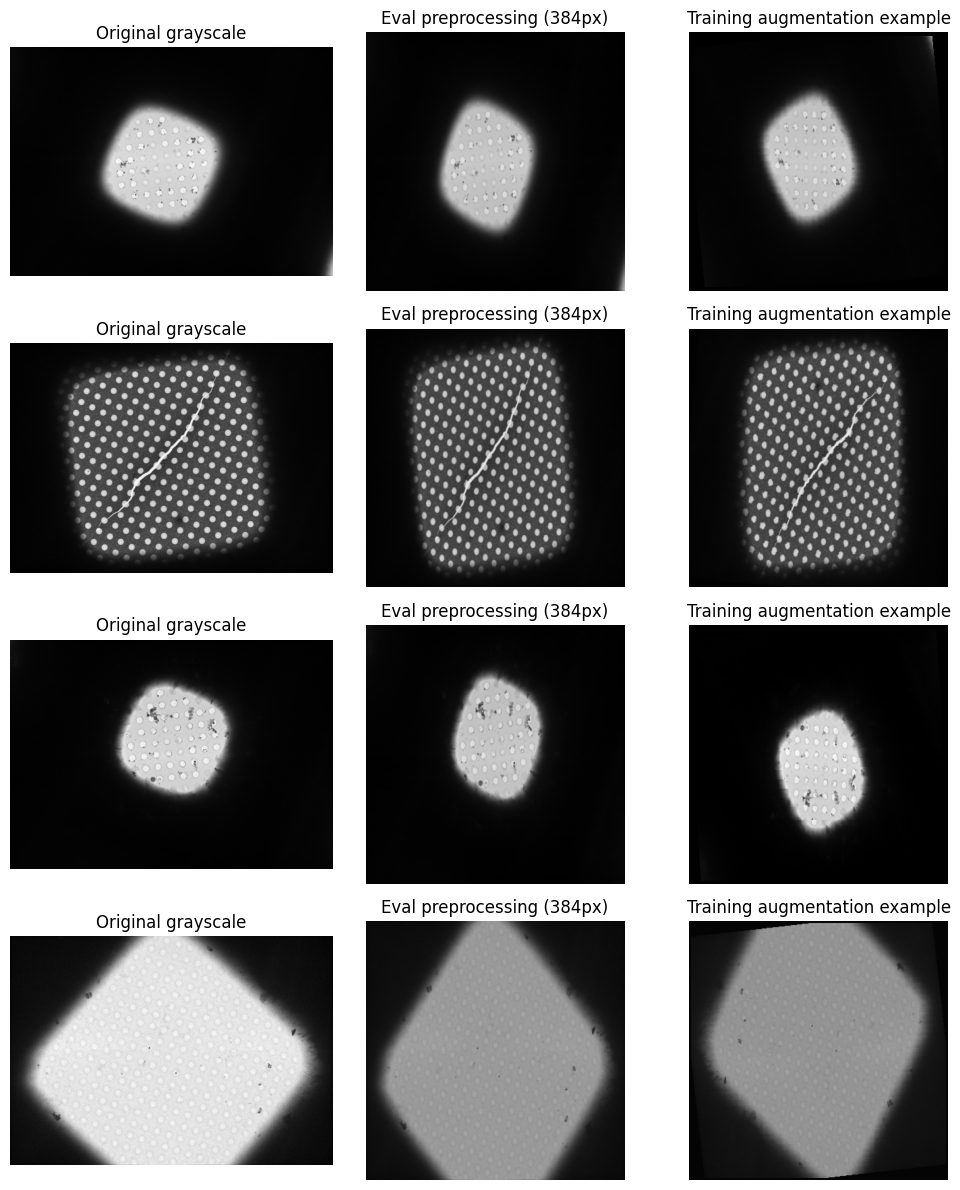

In [7]:
normalize = transforms.Normalize(
    mean=ResNet18_Weights.DEFAULT.transforms().mean,
    std=ResNet18_Weights.DEFAULT.transforms().std,
)

train_steps = [
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
]
if not CFG.orientation_is_meaningful:
    train_steps.append(transforms.RandomVerticalFlip(p=0.5))
train_steps += [
    transforms.RandomRotation(degrees=7, fill=0),
    transforms.RandomAffine(degrees=0, scale=(0.95, 1.05), fill=0),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    normalize,
]

train_transform = transforms.Compose(train_steps)
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.ToTensor(),
    normalize,
])


class AtlasDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform):
        self.frame = frame.reset_index(drop=True).copy()
        self.transform = transform
        self.tag_y = mlb.transform(self.frame["tags_list"]).astype(np.float32)
        self.rating_y = self.frame["rating_label"].to_numpy(dtype=np.int64)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["image_path"]).convert("L")
        image = self.transform(image)
        return {
            "image": image,
            "tags": torch.tensor(self.tag_y[idx], dtype=torch.float32),
            "rating": torch.tensor(self.rating_y[idx], dtype=torch.long),
            "rating_valid": torch.tensor(bool(row["rating_valid"]), dtype=torch.bool),
            "filename": row["combined_key"],
            "image_path": str(row["image_path"]),
        }


def make_loader(frame: pd.DataFrame, transform, shuffle: bool):
    return DataLoader(
        AtlasDataset(frame, transform),
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=torch.cuda.is_available(),
    )


train_loader = make_loader(train_df, train_transform, shuffle=True)
val_loader = make_loader(val_df, eval_transform, shuffle=False)
test_loader = make_loader(test_df, eval_transform, shuffle=False)

batch = next(iter(train_loader))
print("Sanity batch:", batch["image"].shape, batch["tags"].shape, batch["rating"].shape)


def tensor_to_display_image(tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor(ResNet18_Weights.DEFAULT.transforms().mean).view(3, 1, 1)
    std = torch.tensor(ResNet18_Weights.DEFAULT.transforms().std).view(3, 1, 1)
    image = tensor.detach().cpu() * std + mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image


def show_preprocessing_examples(frame: pd.DataFrame, n: int = 4, save_path: Optional[Path] = None):
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_state = torch.random.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        sample = frame.sample(n=min(n, len(frame)), random_state=SEED).reset_index(drop=True)
        fig, axes = plt.subplots(len(sample), 3, figsize=(10, 3 * len(sample)))
        if len(sample) == 1:
            axes = np.array([axes])
        for row_idx, row in sample.iterrows():
            original = Image.open(row["image_path"]).convert("L")
            eval_image = tensor_to_display_image(eval_transform(original))
            augmented_image = tensor_to_display_image(train_transform(original))
            panels = [
                (np.array(original), "Original grayscale", "gray"),
                (eval_image, f"Eval preprocessing ({CFG.image_size}px)", None),
                (augmented_image, "Training augmentation example", None),
            ]
            for col_idx, (image, title, cmap) in enumerate(panels):
                ax = axes[row_idx, col_idx]
                ax.imshow(image, cmap=cmap)
                ax.set_title(title)
                ax.axis("off")
            axes[row_idx, 0].set_ylabel(row["combined_key"], fontsize=8)
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=160)
        plt.show()
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.random.set_rng_state(torch_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)


show_preprocessing_examples(train_df, n=4, save_path=RUN_DIR / "preprocessing_examples.png")

## 8. ResNet18 Multitask Model

In [8]:
class ResNet18SquareExperiment(nn.Module):
    def __init__(self, num_tags: int, num_ratings: int = 3, pretrained: bool = True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        try:
            backbone = models.resnet18(weights=weights)
        except Exception as exc:
            if not pretrained:
                raise
            warnings.warn(
                f"Could not load pretrained weights: {exc}. Falling back to random initialization. "
                "For final training, rerun where torchvision can download or access cached weights."
            )
            backbone = models.resnet18(weights=None)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.tag_head = nn.Linear(feature_dim, num_tags)
        self.rating_head = nn.Linear(feature_dim, num_ratings)

    def forward(self, x):
        features = self.backbone(x)
        return {"tag_logits": self.tag_head(features), "rating_logits": self.rating_head(features)}


def freeze_backbone(model):
    for parameter in model.backbone.parameters():
        parameter.requires_grad = False
    for parameter in list(model.tag_head.parameters()) + list(model.rating_head.parameters()):
        parameter.requires_grad = True


def unfreeze_layer4(model):
    for parameter in model.backbone.layer4.parameters():
        parameter.requires_grad = True


model = ResNet18SquareExperiment(len(TAG_CLASSES), len(RATING_CLASSES), pretrained=CFG.pretrained).to(DEVICE)
if CFG.freeze_backbone_initially:
    freeze_backbone(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Trainable parameters: 3,078 / 11,179,590


## 9. Losses, Optimizer, Scheduler, and Early Stopping

In [9]:
def compute_pos_weight(frame: pd.DataFrame):
    y = mlb.transform(frame["tags_list"]).astype(np.float32)
    pos = y.sum(axis=0)
    neg = len(y) - pos
    weights = np.ones_like(pos, dtype=np.float32)
    has_pos = pos > 0
    weights[has_pos] = neg[has_pos] / np.maximum(pos[has_pos], 1.0)
    return torch.tensor(np.clip(weights, 1.0, 50.0), dtype=torch.float32, device=DEVICE)


def compute_rating_weights(frame: pd.DataFrame):
    valid = frame[frame["rating_valid"]]
    counts = valid["rating_label"].value_counts().reindex(range(len(RATING_CLASSES)), fill_value=0).to_numpy()
    total = counts.sum()
    weights = np.ones(len(RATING_CLASSES), dtype=np.float32)
    nonzero = counts > 0
    weights[nonzero] = total / (len(RATING_CLASSES) * counts[nonzero])
    return torch.tensor(np.clip(weights, 0.25, 12.0), dtype=torch.float32, device=DEVICE)


computed_pos_weight = compute_pos_weight(train_df)
effective_pos_weight = computed_pos_weight if CFG.use_tag_pos_weight else None
rating_weights = compute_rating_weights(train_df)
tag_criterion = nn.BCEWithLogitsLoss(pos_weight=effective_pos_weight)
rating_criterion = nn.CrossEntropyLoss(weight=rating_weights, reduction="none")

print("Computed tag pos_weight:", dict(zip(TAG_CLASSES, computed_pos_weight.detach().cpu().numpy().round(3))))
print("Using tag pos_weight:", CFG.use_tag_pos_weight)
print("Rating weights:", dict(zip(RATING_CLASSES, rating_weights.detach().cpu().numpy().round(3))))


def make_optimizer(lr: float):
    return torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=CFG.weight_decay)


class EarlyStopping:
    def __init__(self, mode="min", patience=5, min_delta=1e-4):
        self.mode = mode
        self.patience = patience
        self.min_delta = min_delta
        self.best = None
        self.bad_epochs = 0

    def step(self, value: float) -> bool:
        if self.best is None:
            self.best = value
            return False
        improved = value < self.best - self.min_delta if self.mode == "min" else value > self.best + self.min_delta
        if improved:
            self.best = value
            self.bad_epochs = 0
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience

Computed tag pos_weight: {'thick ice': np.float32(2.797), 'non-uniform ice': np.float32(2.294), 'ice contamination': np.float32(1.409)}
Using tag pos_weight: False
Rating weights: {'good': np.float32(0.896), 'acceptable': np.float32(1.161), 'unacceptable': np.float32(0.978)}


## 10. Training Loop

In [10]:
def compute_loss(outputs, batch):
    tag_targets = batch["tags"].to(DEVICE)
    rating_targets = batch["rating"].to(DEVICE)
    rating_valid = batch["rating_valid"].to(DEVICE)

    tag_loss = tag_criterion(outputs["tag_logits"], tag_targets)
    if rating_valid.any():
        rating_loss = rating_criterion(outputs["rating_logits"][rating_valid], rating_targets[rating_valid]).mean()
    else:
        rating_loss = torch.zeros((), device=DEVICE)
    loss = CFG.tag_loss_weight * tag_loss + CFG.rating_loss_weight * rating_loss
    return loss, {"tag_loss": float(tag_loss.detach().cpu()), "rating_loss": float(rating_loss.detach().cpu())}


@torch.no_grad()
def collect_predictions(loader, model):
    model.eval()
    tag_probs, tag_true, rating_probs, rating_true, rating_valid = [], [], [], [], []
    filenames, image_paths, losses = [], [], []
    for batch in loader:
        images = batch["image"].to(DEVICE)
        outputs = model(images)
        loss, _ = compute_loss(outputs, batch)
        losses.append(float(loss.detach().cpu()))
        tag_probs.append(torch.sigmoid(outputs["tag_logits"]).detach().cpu().numpy())
        tag_true.append(batch["tags"].numpy())
        rating_probs.append(torch.softmax(outputs["rating_logits"], dim=1).detach().cpu().numpy())
        rating_true.append(batch["rating"].numpy())
        rating_valid.append(batch["rating_valid"].numpy())
        filenames.extend(batch["filename"])
        image_paths.extend(batch["image_path"])
    return {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "tag_probs": np.vstack(tag_probs),
        "tag_true": np.vstack(tag_true).astype(int),
        "rating_probs": np.vstack(rating_probs),
        "rating_true": np.concatenate(rating_true),
        "rating_valid": np.concatenate(rating_valid).astype(bool),
        "filenames": filenames,
        "image_paths": image_paths,
    }


def tag_sample_jaccard_score(tag_true, tag_pred) -> float:
    intersections = np.logical_and(tag_true == 1, tag_pred == 1).sum(axis=1)
    unions = np.logical_or(tag_true == 1, tag_pred == 1).sum(axis=1)
    per_sample = np.where(unions == 0, 1.0, intersections / np.maximum(unions, 1))
    return float(per_sample.mean())


def apply_tag_thresholds(tag_probs, thresholds):
    threshold_array = np.array([thresholds.get(tag, CFG.tag_probability_threshold) for tag in TAG_CLASSES])
    return (tag_probs >= threshold_array[None, :]).astype(int)


def apply_rating_threshold(rating_probs, threshold=None):
    # Gate unacceptable by a tunable threshold, then choose good vs acceptable by argmax.
    threshold = CFG.rating_probability_threshold if threshold is None else float(threshold)
    probs = np.asarray(rating_probs)
    unacceptable_idx = RATING_TO_IDX["unacceptable"]
    non_unacceptable_idx = np.array([idx for idx in range(len(RATING_CLASSES)) if idx != unacceptable_idx])
    pred = non_unacceptable_idx[probs[:, non_unacceptable_idx].argmax(axis=1)]
    pred = pred.astype(int)
    pred[probs[:, unacceptable_idx] >= threshold] = unacceptable_idx
    return pred


def evaluate_basic(loader, tag_threshold=0.5, rating_threshold=0.5):
    preds = collect_predictions(loader, model)
    tag_pred = (preds["tag_probs"] >= tag_threshold).astype(int)
    valid = preds["rating_valid"]
    rating_pred = apply_rating_threshold(preds["rating_probs"], rating_threshold)

    per_tag_accuracy = (preds["tag_true"] == tag_pred).mean(axis=0)
    tag_mean_accuracy = float(per_tag_accuracy.mean())
    tag_min_accuracy = float(per_tag_accuracy.min())
    tag_exact_match = float(np.all(preds["tag_true"] == tag_pred, axis=1).mean())
    weight_total = max(CFG.tag_specific_accuracy_weight + CFG.tag_exact_match_accuracy_weight, 1e-12)
    tag_joint_accuracy = float(
        (
            CFG.tag_specific_accuracy_weight * tag_mean_accuracy
            + CFG.tag_exact_match_accuracy_weight * tag_exact_match
        )
        / weight_total
    )

    metrics = {
        "loss": preds["loss"],
        "tag_micro_f1": f1_score(preds["tag_true"], tag_pred, average="micro", zero_division=0),
        "tag_macro_f1": f1_score(preds["tag_true"], tag_pred, average="macro", zero_division=0),
        "tag_mean_accuracy": tag_mean_accuracy,
        "tag_min_accuracy": tag_min_accuracy,
        "tag_exact_match": tag_exact_match,
        "tag_joint_accuracy": tag_joint_accuracy,
        "tag_sample_jaccard": tag_sample_jaccard_score(preds["tag_true"], tag_pred),
    }
    if valid.any():
        metrics["rating_accuracy"] = accuracy_score(preds["rating_true"][valid], rating_pred[valid])
        metrics["rating_macro_f1"] = f1_score(preds["rating_true"][valid], rating_pred[valid], average="macro", zero_division=0)
        rating_prf = precision_recall_fscore_support(
            preds["rating_true"][valid], rating_pred[valid], labels=[RATING_TO_IDX["unacceptable"]], zero_division=0
        )
        metrics["unacceptable_precision"] = float(rating_prf[0][0])
        metrics["unacceptable_recall"] = float(rating_prf[1][0])
        metrics["unacceptable_f1"] = float(rating_prf[2][0])
        metrics["predicted_unacceptable_fraction"] = float((rating_pred[valid] == RATING_TO_IDX["unacceptable"]).mean())
    else:
        metrics["rating_accuracy"] = np.nan
        metrics["rating_macro_f1"] = np.nan
        metrics["unacceptable_precision"] = np.nan
        metrics["unacceptable_recall"] = np.nan
        metrics["unacceptable_f1"] = np.nan
        metrics["predicted_unacceptable_fraction"] = np.nan
    return metrics

def train_one_epoch(loader, optimizer):
    model.train()
    totals = defaultdict(float)
    n = 0
    for batch in tqdm(loader, desc="train", leave=False):
        images = batch["image"].to(DEVICE)
        outputs = model(images)
        loss, parts = compute_loss(outputs, batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        bsz = images.size(0)
        totals["loss"] += float(loss.detach().cpu()) * bsz
        totals["tag_loss"] += parts["tag_loss"] * bsz
        totals["rating_loss"] += parts["rating_loss"] * bsz
        n += bsz
    return {key: value / max(n, 1) for key, value in totals.items()}


def save_best_state(epoch, phase, metric_value):
    torch.save(model.state_dict(), RUN_DIR / "best_model_state.pt")
    metadata = {
        "epoch": int(epoch),
        "phase": phase,
        "metric_name": CFG.early_stopping_metric,
        "metric_value": float(metric_value),
        "config": asdict(CFG),
        "label_mappings": label_mappings,
    }
    (RUN_DIR / "best_model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")


def run_training_phase(phase: str, epochs: int, lr: float, start_epoch: int):
    optimizer = make_optimizer(lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    mode = "min" if CFG.early_stopping_metric == "val_loss" else "max"
    early = EarlyStopping(mode=mode, patience=CFG.early_stopping_patience, min_delta=CFG.min_delta)
    epoch = start_epoch
    global best_value
    for _ in range(epochs):
        epoch += 1
        train_metrics = train_one_epoch(train_loader, optimizer)
        val_metrics = evaluate_basic(val_loader, CFG.tag_probability_threshold, CFG.rating_probability_threshold)
        scheduler.step(val_metrics["loss"])
        row = {
            "epoch": epoch,
            "phase": phase,
            "lr": optimizer.param_groups[0]["lr"],
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)
        print(row)

        metric_key = CFG.early_stopping_metric.replace("val_", "")
        monitored = val_metrics[metric_key] if CFG.early_stopping_metric.startswith("val_") else row[CFG.early_stopping_metric]
        improved = monitored < best_value - CFG.min_delta if mode == "min" else monitored > best_value + CFG.min_delta
        if improved:
            best_value = monitored
            save_best_state(epoch, phase, monitored)
            print("Saved best model state:", RUN_DIR / "best_model_state.pt")
        if early.step(monitored):
            print(f"Early stopping triggered in {phase} at epoch {epoch}.")
            break
    return epoch


history = []
best_value = math.inf if CFG.early_stopping_metric == "val_loss" else -math.inf

current_epoch = run_training_phase("heads", CFG.head_epochs, CFG.learning_rate, 0)
if CFG.unfreeze_layer4_for_finetune and CFG.fine_tune_epochs > 0:
    unfreeze_layer4(model)
    current_epoch = run_training_phase("fine_tune_layer4", CFG.fine_tune_epochs, CFG.fine_tune_learning_rate, current_epoch)

history_df = pd.DataFrame(history)
history_df.to_csv(RUN_DIR / "training_history.csv", index=False)
if (RUN_DIR / "best_model_state.pt").exists():
    model.load_state_dict(torch.load(RUN_DIR / "best_model_state.pt", map_location=DEVICE, weights_only=True))

{'epoch': 1, 'phase': 'heads', 'lr': 0.001, 'train_loss': 1.7706545442342758, 'train_tag_loss': 0.6415045016578266, 'train_rating_loss': 1.1291500441730022, 'val_loss': 1.8409464756647747, 'val_tag_micro_f1': 0.28, 'val_tag_macro_f1': 0.15053763440860216, 'val_tag_mean_accuracy': 0.6666666666666666, 'val_tag_min_accuracy': 0.5277777777777778, 'val_tag_exact_match': 0.3055555555555556, 'val_tag_joint_accuracy': 0.4861111111111111, 'val_tag_sample_jaccard': 0.3888888888888889, 'val_rating_accuracy': 0.48484848484848486, 'val_rating_macro_f1': 0.4566666666666667, 'val_unacceptable_precision': 0.6, 'val_unacceptable_recall': 0.9, 'val_unacceptable_f1': 0.72, 'val_predicted_unacceptable_fraction': 0.45454545454545453}
Saved best model state: /nsls2/users/mnicholso/cryoemdoc_prototype/outputs/square_analyzer/best_model_state.pt


{'epoch': 2, 'phase': 'heads', 'lr': 0.001, 'train_loss': 1.547309435904026, 'train_tag_loss': 0.575895826199225, 'train_rating_loss': 0.9714136110352618, 'val_loss': 1.5560539464155834, 'val_tag_micro_f1': 0.5116279069767442, 'val_tag_macro_f1': 0.48888888888888893, 'val_tag_mean_accuracy': 0.8055555555555557, 'val_tag_min_accuracy': 0.75, 'val_tag_exact_match': 0.5555555555555556, 'val_tag_joint_accuracy': 0.6805555555555556, 'val_tag_sample_jaccard': 0.5972222222222222, 'val_rating_accuracy': 0.5757575757575758, 'val_rating_macro_f1': 0.5200651200651201, 'val_unacceptable_precision': 0.875, 'val_unacceptable_recall': 0.7, 'val_unacceptable_f1': 0.7777777777777778, 'val_predicted_unacceptable_fraction': 0.24242424242424243}
Saved best model state: /nsls2/users/mnicholso/cryoemdoc_prototype/outputs/square_analyzer/best_model_state.pt


{'epoch': 3, 'phase': 'heads', 'lr': 0.001, 'train_loss': 1.460680631654603, 'train_tag_loss': 0.5143380295485258, 'train_rating_loss': 0.9463425997112479, 'val_loss': 1.3093191186587017, 'val_tag_micro_f1': 0.5652173913043478, 'val_tag_macro_f1': 0.4801346801346802, 'val_tag_mean_accuracy': 0.8148148148148149, 'val_tag_min_accuracy': 0.75, 'val_tag_exact_match': 0.5833333333333334, 'val_tag_joint_accuracy': 0.6990740740740742, 'val_tag_sample_jaccard': 0.6388888888888888, 'val_rating_accuracy': 0.6666666666666666, 'val_rating_macro_f1': 0.6702011438853543, 'val_unacceptable_precision': 0.8888888888888888, 'val_unacceptable_recall': 0.8, 'val_unacceptable_f1': 0.8421052631578947, 'val_predicted_unacceptable_fraction': 0.2727272727272727}
Saved best model state: /nsls2/users/mnicholso/cryoemdoc_prototype/outputs/square_analyzer/best_model_state.pt


{'epoch': 4, 'phase': 'heads', 'lr': 0.001, 'train_loss': 1.342212412506342, 'train_tag_loss': 0.5041814018040895, 'train_rating_loss': 0.8380310043160405, 'val_loss': 1.3869602282842, 'val_tag_micro_f1': 0.5625, 'val_tag_macro_f1': 0.5442890442890443, 'val_tag_mean_accuracy': 0.7407407407407408, 'val_tag_min_accuracy': 0.6111111111111112, 'val_tag_exact_match': 0.4444444444444444, 'val_tag_joint_accuracy': 0.5925925925925926, 'val_tag_sample_jaccard': 0.5509259259259259, 'val_rating_accuracy': 0.48484848484848486, 'val_rating_macro_f1': 0.4785151284007119, 'val_unacceptable_precision': 0.5714285714285714, 'val_unacceptable_recall': 0.8, 'val_unacceptable_f1': 0.6666666666666666, 'val_predicted_unacceptable_fraction': 0.42424242424242425}


{'epoch': 5, 'phase': 'heads', 'lr': 0.001, 'train_loss': 1.2759802964116846, 'train_tag_loss': 0.4708688011659043, 'train_rating_loss': 0.8051114925848586, 'val_loss': 1.2182449201742809, 'val_tag_micro_f1': 0.5652173913043478, 'val_tag_macro_f1': 0.4801346801346802, 'val_tag_mean_accuracy': 0.8148148148148149, 'val_tag_min_accuracy': 0.75, 'val_tag_exact_match': 0.5833333333333334, 'val_tag_joint_accuracy': 0.6990740740740742, 'val_tag_sample_jaccard': 0.6388888888888888, 'val_rating_accuracy': 0.7272727272727273, 'val_rating_macro_f1': 0.7330917874396136, 'val_unacceptable_precision': 1.0, 'val_unacceptable_recall': 0.6, 'val_unacceptable_f1': 0.75, 'val_predicted_unacceptable_fraction': 0.18181818181818182}


...

{'epoch': 11, 'phase': 'fine_tune_layer4', 'lr': 1e-05, 'train_loss': 1.0090571796255452, 'train_tag_loss': 0.41360331646033693, 'train_rating_loss': 0.5954538670235446, 'val_loss': 1.0885282357533772, 'val_tag_micro_f1': 0.5833333333333334, 'val_tag_macro_f1': 0.5528035775713794, 'val_tag_mean_accuracy': 0.8148148148148149, 'val_tag_min_accuracy': 0.7777777777777778, 'val_tag_exact_match': 0.5555555555555556, 'val_tag_joint_accuracy': 0.6851851851851852, 'val_tag_sample_jaccard': 0.6342592592592592, 'val_rating_accuracy': 0.7272727272727273, 'val_rating_macro_f1': 0.7338186110564626, 'val_unacceptable_precision': 1.0, 'val_unacceptable_recall': 0.7, 'val_unacceptable_f1': 0.8235294117647058, 'val_predicted_unacceptable_fraction': 0.21212121212121213}


{'epoch': 12, 'phase': 'fine_tune_layer4', 'lr': 1e-05, 'train_loss': 1.0472199765167065, 'train_tag_loss': 0.4007604392245412, 'train_rating_loss': 0.646459541416594, 'val_loss': 1.0981032997369766, 'val_tag_micro_f1': 0.5957446808510638, 'val_tag_macro_f1': 0.5797720797720798, 'val_tag_mean_accuracy': 0.8240740740740741, 'val_tag_min_accuracy': 0.7777777777777778, 'val_tag_exact_match': 0.6111111111111112, 'val_tag_joint_accuracy': 0.7175925925925926, 'val_tag_sample_jaccard': 0.662037037037037, 'val_rating_accuracy': 0.7272727272727273, 'val_rating_macro_f1': 0.7338186110564626, 'val_unacceptable_precision': 1.0, 'val_unacceptable_recall': 0.7, 'val_unacceptable_f1': 0.8235294117647058, 'val_predicted_unacceptable_fraction': 0.21212121212121213}


{'epoch': 13, 'phase': 'fine_tune_layer4', 'lr': 1e-05, 'train_loss': 1.0015561862715654, 'train_tag_loss': 0.3930091661001955, 'train_rating_loss': 0.6085470180426326, 'val_loss': 1.0887696593999863, 'val_tag_micro_f1': 0.5957446808510638, 'val_tag_macro_f1': 0.5797720797720798, 'val_tag_mean_accuracy': 0.8240740740740741, 'val_tag_min_accuracy': 0.7777777777777778, 'val_tag_exact_match': 0.6111111111111112, 'val_tag_joint_accuracy': 0.7175925925925926, 'val_tag_sample_jaccard': 0.662037037037037, 'val_rating_accuracy': 0.7272727272727273, 'val_rating_macro_f1': 0.7338186110564626, 'val_unacceptable_precision': 1.0, 'val_unacceptable_recall': 0.7, 'val_unacceptable_f1': 0.8235294117647058, 'val_predicted_unacceptable_fraction': 0.21212121212121213}


{'epoch': 14, 'phase': 'fine_tune_layer4', 'lr': 1e-05, 'train_loss': 0.971067368185946, 'train_tag_loss': 0.39088256736951216, 'train_rating_loss': 0.5801848034773555, 'val_loss': 1.0653042793273926, 'val_tag_micro_f1': 0.6, 'val_tag_macro_f1': 0.5505050505050505, 'val_tag_mean_accuracy': 0.8148148148148148, 'val_tag_min_accuracy': 0.7777777777777778, 'val_tag_exact_match': 0.5833333333333334, 'val_tag_joint_accuracy': 0.6990740740740741, 'val_tag_sample_jaccard': 0.6481481481481481, 'val_rating_accuracy': 0.7272727272727273, 'val_rating_macro_f1': 0.7338186110564626, 'val_unacceptable_precision': 1.0, 'val_unacceptable_recall': 0.7, 'val_unacceptable_f1': 0.8235294117647058, 'val_predicted_unacceptable_fraction': 0.21212121212121213}


{'epoch': 15, 'phase': 'fine_tune_layer4', 'lr': 1e-05, 'train_loss': 0.9799825980194977, 'train_tag_loss': 0.3826879322794931, 'train_rating_loss': 0.597294661349484, 'val_loss': 1.0951105256875355, 'val_tag_micro_f1': 0.6, 'val_tag_macro_f1': 0.561157796451914, 'val_tag_mean_accuracy': 0.8148148148148149, 'val_tag_min_accuracy': 0.7777777777777778, 'val_tag_exact_match': 0.5555555555555556, 'val_tag_joint_accuracy': 0.6851851851851852, 'val_tag_sample_jaccard': 0.6342592592592592, 'val_rating_accuracy': 0.7272727272727273, 'val_rating_macro_f1': 0.7275882012724119, 'val_unacceptable_precision': 0.8888888888888888, 'val_unacceptable_recall': 0.8, 'val_unacceptable_f1': 0.8421052631578947, 'val_predicted_unacceptable_fraction': 0.2727272727272727}
Early stopping triggered in fine_tune_layer4 at epoch 15.


## 11. Threshold Tuning and Evaluation

In [11]:
def tag_sample_jaccard_score(tag_true, tag_pred) -> float:
    intersections = np.logical_and(tag_true == 1, tag_pred == 1).sum(axis=1)
    unions = np.logical_or(tag_true == 1, tag_pred == 1).sum(axis=1)
    per_sample = np.where(unions == 0, 1.0, intersections / np.maximum(unions, 1))
    return float(per_sample.mean())


def binary_tag_metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    n = max(len(y_true), 1)
    accuracy = (tp + tn) / n
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    if (tp + fn) and (tn + fp):
        balanced_accuracy = 0.5 * (recall + specificity)
    elif tp + fn:
        balanced_accuracy = recall
    else:
        balanced_accuracy = specificity
    f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "support": int((y_true == 1).sum()),
        "negative_support": int((y_true == 0).sum()),
        "predicted_positive": int((y_pred == 1).sum()),
        "true_positive": tp,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
    }


def score_tag_thresholds(tag_true, tag_pred) -> Dict[str, float]:
    per_tag_accuracy = (tag_true == tag_pred).mean(axis=0).astype(float)
    per_tag_balanced_accuracy = np.array([
        binary_tag_metrics(tag_true[:, i], tag_pred[:, i])["balanced_accuracy"]
        for i in range(tag_true.shape[1])
    ])
    mean_tag_accuracy = float(per_tag_accuracy.mean())
    min_tag_accuracy = float(per_tag_accuracy.min())
    exact_match = float(np.all(tag_true == tag_pred, axis=1).mean())
    macro_f1 = float(f1_score(tag_true, tag_pred, average="macro", zero_division=0))
    sample_jaccard = tag_sample_jaccard_score(tag_true, tag_pred)
    macro_balanced_accuracy = float(per_tag_balanced_accuracy.mean())

    weight_total = max(CFG.tag_specific_accuracy_weight + CFG.tag_exact_match_accuracy_weight, 1e-12)
    joint_accuracy = float(
        (
            CFG.tag_specific_accuracy_weight * mean_tag_accuracy
            + CFG.tag_exact_match_accuracy_weight * exact_match
        )
        / weight_total
    )

    objective = CFG.tag_threshold_objective
    if objective == "specific_and_all_accuracy":
        selection_score = joint_accuracy
    elif objective in {"exact_match", "all_tag_accuracy"}:
        selection_score = exact_match
    elif objective in {"mean_tag_accuracy", "specific_tag_accuracy"}:
        selection_score = mean_tag_accuracy
    elif objective == "jaccard":
        selection_score = sample_jaccard
    elif objective == "macro_f1":
        selection_score = macro_f1
    else:
        warnings.warn(f"Unknown tag threshold objective {objective!r}; using specific_and_all_accuracy.")
        selection_score = joint_accuracy

    return {
        "selection_score": float(selection_score),
        "joint_accuracy": joint_accuracy,
        "mean_tag_accuracy": mean_tag_accuracy,
        "min_tag_accuracy": min_tag_accuracy,
        "exact_match": exact_match,
        "macro_balanced_accuracy": macro_balanced_accuracy,
        "macro_f1": macro_f1,
        "sample_jaccard": sample_jaccard,
    }


def _minimum_allowed_threshold(tag: str) -> float:
    if CFG.minimum_tag_thresholds and tag in CFG.minimum_tag_thresholds:
        return float(CFG.minimum_tag_thresholds[tag])
    return 0.0


def validation_threshold_candidates(probabilities, tag: str, default: float = 0.5) -> List[float]:
    """Return every threshold region that can produce a distinct validation prediction."""
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = probabilities[np.isfinite(probabilities)]
    floor = _minimum_allowed_threshold(tag)
    if probabilities.size == 0:
        return [float(max(default, floor))]

    values = np.unique(np.clip(probabilities, 0.0, 1.0))
    candidates = {0.0, 1.0, float(default), float(floor)}
    if len(values) == 1:
        p = float(values[0])
        candidates.add(max(0.0, p - 1e-8))
        candidates.add(min(1.0, p + 1e-8))
    else:
        candidates.add(max(0.0, float(values[0]) - 1e-8))
        candidates.add(min(1.0, float(values[-1]) + 1e-8))
        candidates.update(float((left + right) / 2.0) for left, right in zip(values[:-1], values[1:]))

    return sorted({round(float(value), 10) for value in candidates if floor <= value <= 1.0})


def build_tag_threshold_sweep(tag_true, tag_probs, default: float = 0.5) -> pd.DataFrame:
    rows = []
    for i, tag in enumerate(TAG_CLASSES):
        y_true = tag_true[:, i]
        for threshold in validation_threshold_candidates(tag_probs[:, i], tag, default):
            y_pred = (tag_probs[:, i] >= threshold).astype(int)
            rows.append({"tag": tag, "threshold": float(threshold), **binary_tag_metrics(y_true, y_pred)})
    return pd.DataFrame(rows)


def _individual_threshold_rank(row: Dict[str, Any]) -> Tuple[float, ...]:
    # Raw per-tag accuracy is primary. Balanced accuracy and F1 only break ties
    # so a majority-class shortcut is not preferred when raw accuracy is equal.
    return (
        float(row["accuracy"]),
        float(row["balanced_accuracy"]),
        float(row["f1"]),
        float(row["precision"]),
        float(row["recall"]),
        float(row["threshold"]),
    )


def _global_threshold_rank(scores: Dict[str, float], thresholds: Dict[str, float]) -> Tuple[float, ...]:
    # The configured joint score values individual-tag and exact whole-set
    # accuracy equally by default. Remaining metrics are deterministic tie-breakers.
    return (
        float(scores["selection_score"]),
        float(scores["exact_match"]),
        float(scores["mean_tag_accuracy"]),
        float(scores["min_tag_accuracy"]),
        float(scores["macro_balanced_accuracy"]),
        float(scores["macro_f1"]),
        float(scores["sample_jaccard"]),
        float(np.mean(list(thresholds.values()))),
    )


def tune_tag_thresholds(tag_true, tag_probs, default=0.5):
    """
    Optimize individual tag accuracy and complete tag-set accuracy.

    For the current three-tag problem this evaluates every distinct validation
    decision-boundary combination, so no better combination exists on the
    validation set under the selected objective.
    """
    sweep_df = build_tag_threshold_sweep(tag_true, tag_probs, default)
    candidate_lists: Dict[str, List[float]] = {}
    individual_best: Dict[str, float] = {}

    for tag in TAG_CLASSES:
        tag_rows = sweep_df[sweep_df["tag"] == tag].to_dict(orient="records")
        tag_rows.sort(key=_individual_threshold_rank, reverse=True)
        individual_best[tag] = float(tag_rows[0]["threshold"])
        candidate_lists[tag] = sorted({float(row["threshold"]) for row in tag_rows})

    full_combination_count = int(math.prod(len(candidate_lists[tag]) for tag in TAG_CLASSES))
    search_method = "exhaustive"

    if full_combination_count > CFG.max_exhaustive_threshold_combinations:
        search_method = "pruned_exhaustive"
        per_tag_limit = max(
            2,
            int(CFG.max_exhaustive_threshold_combinations ** (1.0 / max(len(TAG_CLASSES), 1))),
        )
        for tag in TAG_CLASSES:
            ranked_rows = sweep_df[sweep_df["tag"] == tag].to_dict(orient="records")
            ranked_rows.sort(key=_individual_threshold_rank, reverse=True)
            retained = ranked_rows[:per_tag_limit]
            candidate_lists[tag] = sorted({float(row["threshold"]) for row in retained} | {individual_best[tag]})

    evaluated_combination_count = int(math.prod(len(candidate_lists[tag]) for tag in TAG_CLASSES))
    best_thresholds = dict(individual_best)
    best_scores = score_tag_thresholds(tag_true, apply_tag_thresholds(tag_probs, best_thresholds))
    best_rank = _global_threshold_rank(best_scores, best_thresholds)
    top_records: List[Tuple[Tuple[float, ...], Dict[str, Any]]] = []

    candidate_arrays = [candidate_lists[tag] for tag in TAG_CLASSES]
    for combination in product(*candidate_arrays):
        thresholds = {tag: float(value) for tag, value in zip(TAG_CLASSES, combination)}
        tag_pred = apply_tag_thresholds(tag_probs, thresholds)
        scores = score_tag_thresholds(tag_true, tag_pred)
        rank = _global_threshold_rank(scores, thresholds)
        if rank > best_rank:
            best_rank = rank
            best_scores = scores
            best_thresholds = thresholds

        record = {**{f"threshold__{tag}": thresholds[tag] for tag in TAG_CLASSES}, **scores}
        top_records.append((rank, record))
        if len(top_records) > max(CFG.max_saved_threshold_combinations * 4, 400):
            top_records.sort(key=lambda item: item[0], reverse=True)
            top_records = top_records[:CFG.max_saved_threshold_combinations]

    top_records.sort(key=lambda item: item[0], reverse=True)
    top_df = pd.DataFrame([record for _, record in top_records[:CFG.max_saved_threshold_combinations]])
    search_info = {
        "method": search_method,
        "full_combination_count": full_combination_count,
        "evaluated_combination_count": evaluated_combination_count,
        "candidate_count_by_tag": {tag: len(candidate_lists[tag]) for tag in TAG_CLASSES},
        "individual_accuracy_best_thresholds": individual_best,
        "selected_scores": best_scores,
    }
    return best_thresholds, sweep_df, top_df, search_info


def build_tag_threshold_report(tag_true, tag_probs, thresholds, threshold_sweep_df=None):
    tag_pred = apply_tag_thresholds(tag_probs, thresholds)
    overall_scores = score_tag_thresholds(tag_true, tag_pred)
    rows = []
    for i, tag in enumerate(TAG_CLASSES):
        metrics = binary_tag_metrics(tag_true[:, i], tag_pred[:, i])
        individual_best_threshold = np.nan
        individual_best_accuracy = np.nan
        if threshold_sweep_df is not None and not threshold_sweep_df.empty:
            tag_sweep = threshold_sweep_df[threshold_sweep_df["tag"] == tag].to_dict(orient="records")
            if tag_sweep:
                tag_sweep.sort(key=_individual_threshold_rank, reverse=True)
                individual_best_threshold = float(tag_sweep[0]["threshold"])
                individual_best_accuracy = float(tag_sweep[0]["accuracy"])
        rows.append({
            "tag": tag,
            "selected_threshold": thresholds[tag],
            "individual_accuracy_best_threshold": individual_best_threshold,
            "individual_accuracy_best": individual_best_accuracy,
            **metrics,
            **overall_scores,
        })
    return pd.DataFrame(rows)


def build_rating_threshold_sweep(rating_true, rating_probs, valid):
    y_true = rating_true[valid]
    probs = rating_probs[valid]
    unacceptable_idx = RATING_TO_IDX["unacceptable"]
    rows = []
    for threshold in CFG.threshold_grid:
        y_pred = apply_rating_threshold(probs, threshold)
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=[unacceptable_idx], zero_division=0
        )
        rows.append({
            "threshold": float(threshold),
            "unacceptable_precision": float(precision[0]),
            "unacceptable_recall": float(recall[0]),
            "unacceptable_f1": float(f1[0]),
            "unacceptable_support": int(support[0]) if len(support) else 0,
            "macro_f1": float(f1_score(y_true, y_pred, labels=list(range(len(RATING_CLASSES))), average="macro", zero_division=0)),
            "accuracy": float(accuracy_score(y_true, y_pred)) if len(y_true) else np.nan,
            "predicted_unacceptable": int((y_pred == unacceptable_idx).sum()),
            "predicted_unacceptable_fraction": float((y_pred == unacceptable_idx).mean()) if len(y_pred) else np.nan,
        })
    return pd.DataFrame(rows)


def tune_rating_threshold(rating_true, rating_probs, valid, default=0.5):
    y_true = rating_true[valid]
    if len(np.unique(y_true)) < 2:
        return default, build_rating_threshold_sweep(rating_true, rating_probs, valid)
    sweep_df = build_rating_threshold_sweep(rating_true, rating_probs, valid)
    candidates = sweep_df.copy()
    if CFG.max_predicted_unacceptable_fraction is not None:
        capped = candidates[candidates["predicted_unacceptable_fraction"] <= CFG.max_predicted_unacceptable_fraction]
        if not capped.empty:
            candidates = capped
        else:
            warnings.warn(
                "No threshold satisfied max_predicted_unacceptable_fraction; falling back to the full threshold sweep."
            )

    if CFG.rating_threshold_objective == "unacceptable_recall_at_precision":
        precision_ok = candidates[candidates["unacceptable_precision"] >= CFG.min_unacceptable_precision]
        if precision_ok.empty:
            warnings.warn(
                "No threshold met min_unacceptable_precision; falling back to unacceptable_f1."
            )
            candidates = candidates.assign(selection_score=candidates["unacceptable_f1"])
            sort_cols = ["selection_score", "macro_f1", "unacceptable_recall", "threshold"]
        else:
            candidates = precision_ok.assign(selection_score=precision_ok["unacceptable_recall"])
            sort_cols = ["selection_score", "unacceptable_f1", "macro_f1", "threshold"]
    elif CFG.rating_threshold_objective == "macro_f1":
        candidates = candidates.assign(selection_score=candidates["macro_f1"])
        sort_cols = ["selection_score", "unacceptable_f1", "unacceptable_recall", "threshold"]
    else:
        candidates = candidates.assign(selection_score=candidates["unacceptable_f1"])
        sort_cols = ["selection_score", "macro_f1", "unacceptable_recall", "threshold"]

    # Ties prefer stronger balanced metrics and then the higher threshold, which avoids the
    # degenerate low-threshold solution that marks almost everything unacceptable.
    chosen = candidates.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0]
    return float(chosen["threshold"]), sweep_df


def tags_from_binary(row, no_issue_label=None):
    labels = [TAG_CLASSES[i] for i, value in enumerate(row) if value]
    if labels:
        return labels
    return no_issue_label if no_issue_label is not None else []


def postprocess_predicted_tags(tags) -> List[str]:
    tag_list = list(tags) if not isinstance(tags, str) else [tag.strip() for tag in tags.split(";") if tag.strip()]
    issue_tags = [tag for tag in tag_list if tag != "no tags"]
    return issue_tags if issue_tags else ["no tags"]


def recommendations_from_tags(tags) -> List[str]:
    tag_set = set(postprocess_predicted_tags(tags))
    recommendations = []

    if "thick ice" in tag_set:
        recommendations.append("increase blotting force/time")
    if "non-uniform ice" in tag_set:
        recommendations.append("increase glow discharge time")
    if "ice contamination" in tag_set:
        recommendations.append("careful handling")

    return recommendations or ["no recommendation"]


def compute_full_metrics(preds, tag_thresholds, rating_threshold):
    tag_true = preds["tag_true"]
    tag_pred = apply_tag_thresholds(preds["tag_probs"], tag_thresholds)
    precision, recall, f1, support = precision_recall_fscore_support(tag_true, tag_pred, average=None, zero_division=0)
    tag_accuracy = (tag_true == tag_pred).mean(axis=0)
    predicted_positive = tag_pred.sum(axis=0)
    true_positive = ((tag_true == 1) & (tag_pred == 1)).sum(axis=0)
    true_negative = ((tag_true == 0) & (tag_pred == 0)).sum(axis=0)
    false_positive = ((tag_true == 0) & (tag_pred == 1)).sum(axis=0)
    false_negative = ((tag_true == 1) & (tag_pred == 0)).sum(axis=0)
    per_tag_df = pd.DataFrame({
        "tag": TAG_CLASSES,
        "accuracy": tag_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "predicted_positive": predicted_positive,
        "true_positive": true_positive,
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "threshold": [tag_thresholds[tag] for tag in TAG_CLASSES],
    })

    threshold_scores = score_tag_thresholds(tag_true, tag_pred)
    metrics = {
        "loss": preds["loss"],
        "tag_micro_f1": f1_score(tag_true, tag_pred, average="micro", zero_division=0),
        "tag_macro_f1": f1_score(tag_true, tag_pred, average="macro", zero_division=0),
        "tag_mean_accuracy": threshold_scores["mean_tag_accuracy"],
        "tag_min_accuracy": threshold_scores["min_tag_accuracy"],
        "tag_joint_accuracy": threshold_scores["joint_accuracy"],
        "tag_exact_match_accuracy": threshold_scores["exact_match"],
        "tag_macro_balanced_accuracy": threshold_scores["macro_balanced_accuracy"],
        "tag_sample_jaccard": threshold_scores["sample_jaccard"],
    }

    rating_pred = apply_rating_threshold(preds["rating_probs"], rating_threshold)
    valid = preds["rating_valid"]
    if valid.any():
        metrics["rating_accuracy"] = accuracy_score(preds["rating_true"][valid], rating_pred[valid])
        metrics["rating_macro_f1"] = f1_score(preds["rating_true"][valid], rating_pred[valid], average="macro", zero_division=0)
        rating_prf = precision_recall_fscore_support(
            preds["rating_true"][valid],
            rating_pred[valid],
            labels=list(range(len(RATING_CLASSES))),
            zero_division=0,
        )
        for class_idx, class_name in enumerate(RATING_CLASSES):
            metrics[f"{class_name}_precision"] = float(rating_prf[0][class_idx])
            metrics[f"{class_name}_recall"] = float(rating_prf[1][class_idx])
            metrics[f"{class_name}_f1"] = float(rating_prf[2][class_idx])
        metrics["rating_report"] = classification_report(
            preds["rating_true"][valid],
            rating_pred[valid],
            labels=list(range(len(RATING_CLASSES))),
            target_names=RATING_CLASSES,
            output_dict=True,
            zero_division=0,
        )
        cm = confusion_matrix(preds["rating_true"][valid], rating_pred[valid], labels=list(range(len(RATING_CLASSES))))
    else:
        metrics["rating_accuracy"] = None
        metrics["rating_macro_f1"] = None
        metrics["rating_report"] = None
        cm = np.zeros((len(RATING_CLASSES), len(RATING_CLASSES)), dtype=int)

    rows = []
    for i, filename in enumerate(preds["filenames"]):
        true_tag_labels = postprocess_predicted_tags(tags_from_binary(tag_true[i], []))
        predicted_tag_labels = postprocess_predicted_tags(tags_from_binary(tag_pred[i], []))
        row = {
            "filename": filename,
            "image_path": preds["image_paths"][i],
            "true_tags": "; ".join(true_tag_labels),
            "predicted_tags": "; ".join(predicted_tag_labels),
            "recommendations": "; ".join(recommendations_from_tags(predicted_tag_labels)),
            "true_rating": IDX_TO_RATING.get(int(preds["rating_true"][i]), "invalid_or_missing"),
            "predicted_rating": IDX_TO_RATING[int(rating_pred[i])],
            "rating_valid": bool(valid[i]),
            "prob_good": float(preds["rating_probs"][i, RATING_TO_IDX["good"]]),
            "prob_unacceptable": float(preds["rating_probs"][i, RATING_TO_IDX["unacceptable"]]),
            "prob_acceptable": float(preds["rating_probs"][i, RATING_TO_IDX["acceptable"]]),
        }
        row.update({f"prob_tag__{tag}": float(preds["tag_probs"][i, j]) for j, tag in enumerate(TAG_CLASSES)})
        rows.append(row)
    return metrics, per_tag_df, cm, pd.DataFrame(rows)


val_preds = collect_predictions(val_loader, model)
if CFG.tune_tag_thresholds:
    tag_thresholds, tag_threshold_sweep_df, tag_threshold_top_combinations_df, tag_threshold_search_info = tune_tag_thresholds(
        val_preds["tag_true"], val_preds["tag_probs"], CFG.tag_probability_threshold
    )
else:
    tag_thresholds = {tag: CFG.tag_probability_threshold for tag in TAG_CLASSES}
    tag_threshold_sweep_df = build_tag_threshold_sweep(
        val_preds["tag_true"], val_preds["tag_probs"], CFG.tag_probability_threshold
    )
    tag_threshold_top_combinations_df = pd.DataFrame()
    tag_threshold_search_info = {
        "method": "disabled",
        "selected_scores": score_tag_thresholds(
            val_preds["tag_true"], apply_tag_thresholds(val_preds["tag_probs"], tag_thresholds)
        ),
    }

tag_threshold_report_df = build_tag_threshold_report(
    val_preds["tag_true"], val_preds["tag_probs"], tag_thresholds, tag_threshold_sweep_df
)
tag_threshold_report_df.to_csv(RUN_DIR / "tag_threshold_report.csv", index=False)
tag_threshold_sweep_df.to_csv(RUN_DIR / "tag_threshold_sweep.csv", index=False)
tag_threshold_top_combinations_df.to_csv(RUN_DIR / "tag_threshold_top_combinations.csv", index=False)

if CFG.tune_rating_threshold:
    rating_threshold, rating_threshold_sweep_df = tune_rating_threshold(
        val_preds["rating_true"], val_preds["rating_probs"], val_preds["rating_valid"], CFG.rating_probability_threshold
    )
else:
    rating_threshold = CFG.rating_probability_threshold
    rating_threshold_sweep_df = build_rating_threshold_sweep(
        val_preds["rating_true"], val_preds["rating_probs"], val_preds["rating_valid"]
    )
rating_threshold_sweep_df.to_csv(RUN_DIR / "rating_threshold_sweep.csv", index=False)

threshold_payload = {
    "tag_thresholds": tag_thresholds,
    "minimum_tag_thresholds": CFG.minimum_tag_thresholds,
    "tag_threshold_objective": CFG.tag_threshold_objective,
    "tag_specific_accuracy_weight": CFG.tag_specific_accuracy_weight,
    "tag_exact_match_accuracy_weight": CFG.tag_exact_match_accuracy_weight,
    "tag_threshold_search": tag_threshold_search_info,
    "use_tag_pos_weight": CFG.use_tag_pos_weight,
    "rating_prediction_rule": "unacceptable_threshold_then_good_acceptable_argmax",
    "rating_threshold": rating_threshold,
    "rating_threshold_objective": CFG.rating_threshold_objective,
    "min_unacceptable_precision": CFG.min_unacceptable_precision,
    "max_predicted_unacceptable_fraction": CFG.max_predicted_unacceptable_fraction,
}
(RUN_DIR / "thresholds.json").write_text(json.dumps(threshold_payload, indent=2), encoding="utf-8")
print(threshold_payload)
display(tag_threshold_report_df)
display(rating_threshold_sweep_df)

test_preds = collect_predictions(test_loader, model)
val_metrics, val_per_tag_df, val_cm, val_prediction_df = compute_full_metrics(val_preds, tag_thresholds, rating_threshold)
test_metrics, test_per_tag_df, test_cm, test_prediction_df = compute_full_metrics(test_preds, tag_thresholds, rating_threshold)

metrics_payload = {
    "validation": val_metrics,
    "test": test_metrics,
    "missing_images_count": len(missing_images),
    "duplicate_csv_filenames_count": int(len(duplicate_csv_filenames)),
    "run_dir": str(RUN_DIR),
}
(RUN_DIR / "validation_test_metrics.json").write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")
test_per_tag_df.to_csv(RUN_DIR / "per_tag_metrics.csv", index=False)
test_prediction_df.to_csv(RUN_DIR / "prediction_csv.csv", index=False)
val_prediction_df.to_csv(RUN_DIR / "validation_prediction_csv.csv", index=False)

display(pd.json_normalize(val_metrics, sep="."))
display(pd.json_normalize(test_metrics, sep="."))
display(test_per_tag_df)

{'tag_thresholds': {'thick ice': 0.3444033116, 'non-uniform ice': 0.5350544155, 'ice contamination': 0.5}, 'minimum_tag_thresholds': None, 'tag_threshold_objective': 'specific_and_all_accuracy', 'tag_specific_accuracy_weight': 0.5, 'tag_exact_match_accuracy_weight': 0.5, 'tag_threshold_search': {'method': 'exhaustive', 'full_combination_count': 64000, 'evaluated_combination_count': 64000, 'candidate_count_by_tag': {'thick ice': 40, 'non-uniform ice': 40, 'ice contamination': 40}, 'individual_accuracy_best_thresholds': {'thick ice': 0.1196973249, 'non-uniform ice': 0.5350544155, 'ice contamination': 0.5}, 'selected_scores': {'selection_score': 0.7638888888888888, 'joint_accuracy': 0.7638888888888888, 'mean_tag_accuracy': 0.8611111111111112, 'min_tag_accuracy': 0.8333333333333334, 'exact_match': 0.6666666666666666, 'macro_balanced_accuracy': 0.7688636363636364, 'macro_f1': 0.6767676767676768, 'sample_jaccard': 0.7083333333333334}}, 'use_tag_pos_weight': False, 'rating_prediction_rule': '

,tag,selected_threshold,individual_accuracy_best_threshold,individual_accuracy_best,accuracy,balanced_accuracy,precision,recall,specificity,f1,...,false_positive,false_negative,selection_score,joint_accuracy,mean_tag_accuracy,min_tag_accuracy,exact_match,macro_balanced_accuracy,macro_f1,sample_jaccard
0,thick ice,0.344403,0.119697,0.888889,0.888889,0.869091,0.818182,0.818182,0.92,0.818182,...,2,2,0.763889,0.763889,0.861111,0.833333,0.666667,0.768864,0.676768,0.708333
1,non-uniform ice,0.535054,0.535054,0.861111,0.861111,0.687500,1.000000,0.375000,1.00,0.545455,...,0,5,0.763889,0.763889,0.861111,0.833333,0.666667,0.768864,0.676768,0.708333
2,ice contamination,0.500000,0.500000,0.833333,0.833333,0.750000,1.000000,0.500000,1.00,0.666667,...,0,6,0.763889,0.763889,0.861111,0.833333,0.666667,0.768864,0.676768,0.708333


,threshold,unacceptable_precision,unacceptable_recall,unacceptable_f1,unacceptable_support,macro_f1,accuracy,predicted_unacceptable,predicted_unacceptable_fraction
0,0.01,0.454545,1.0,0.625000,10,0.552193,0.575758,22,0.666667
1,0.02,0.526316,1.0,0.689655,10,0.605643,0.636364,19,0.575758
2,0.03,0.529412,0.9,0.666667,10,0.608092,0.636364,17,0.515152
3,0.04,0.562500,0.9,0.692308,10,0.648502,0.666667,16,0.484848
4,0.05,0.533333,0.8,0.640000,10,0.622351,0.636364,15,0.454545
...,...,...,...,...,...,...,...,...,...
94,0.95,0.000000,0.0,0.000000,10,0.465278,0.575758,0,0.000000
95,0.96,0.000000,0.0,0.000000,10,0.465278,0.575758,0,0.000000
96,0.97,0.000000,0.0,0.000000,10,0.465278,0.575758,0,0.000000
97,0.98,0.000000,0.0,0.000000,10,0.465278,0.575758,0,0.000000


,loss,tag_micro_f1,tag_macro_f1,tag_mean_accuracy,tag_min_accuracy,tag_joint_accuracy,tag_exact_match_accuracy,tag_macro_balanced_accuracy,tag_sample_jaccard,rating_accuracy,...,rating_report.unacceptable.support,rating_report.accuracy,rating_report.macro avg.precision,rating_report.macro avg.recall,rating_report.macro avg.f1-score,rating_report.macro avg.support,rating_report.weighted avg.precision,rating_report.weighted avg.recall,rating_report.weighted avg.f1-score,rating_report.weighted avg.support
0,1.099021,0.705882,0.676768,0.861111,0.833333,0.763889,0.666667,0.768864,0.708333,0.818182,...,10.0,0.818182,0.839744,0.819697,0.824074,33.0,0.832168,0.818182,0.819865,33.0


,loss,tag_micro_f1,tag_macro_f1,tag_mean_accuracy,tag_min_accuracy,tag_joint_accuracy,tag_exact_match_accuracy,tag_macro_balanced_accuracy,tag_sample_jaccard,rating_accuracy,...,rating_report.unacceptable.support,rating_report.accuracy,rating_report.macro avg.precision,rating_report.macro avg.recall,rating_report.macro avg.f1-score,rating_report.macro avg.support,rating_report.weighted avg.precision,rating_report.weighted avg.recall,rating_report.weighted avg.f1-score,rating_report.weighted avg.support
0,1.054951,0.605263,0.563492,0.821429,0.678571,0.678571,0.535714,0.809762,0.633929,0.642857,...,13.0,0.642857,0.722424,0.657467,0.669276,56.0,0.708506,0.642857,0.658114,56.0


,tag,accuracy,precision,recall,f1,support,predicted_positive,true_positive,true_negative,false_positive,false_negative,threshold
0,thick ice,0.892857,0.333333,1.000000,0.500000,3,9,3,47,6,0,0.344403
1,non-uniform ice,0.678571,1.000000,0.217391,0.357143,23,5,5,33,0,18,0.535054
2,ice contamination,0.892857,0.833333,0.833333,0.833333,18,18,15,35,3,3,0.500000


## 12. Error Analysis and Active Learning Exports

In [12]:
false_negative_unacceptable = test_prediction_df[
    (test_prediction_df["rating_valid"]) &
    (test_prediction_df["true_rating"] == "unacceptable") &
    (test_prediction_df["predicted_rating"] != "unacceptable")
].sort_values("prob_unacceptable", ascending=False)

false_positive_unacceptable = test_prediction_df[
    (test_prediction_df["rating_valid"]) &
    (test_prediction_df["true_rating"] != "unacceptable") &
    (test_prediction_df["predicted_rating"] == "unacceptable")
].sort_values("prob_unacceptable", ascending=False)

def uncertainty_score(row):
    rating_margin = abs(float(row["prob_unacceptable"]) - rating_threshold)
    tag_margins = [abs(float(row[f"prob_tag__{tag}"]) - tag_thresholds[tag]) for tag in TAG_CLASSES]
    return min([rating_margin] + tag_margins)

uncertainty_df = test_prediction_df.copy()
uncertainty_df["uncertainty_score"] = uncertainty_df.apply(uncertainty_score, axis=1)
uncertainty_df = uncertainty_df.sort_values("uncertainty_score", ascending=True)

false_negative_unacceptable.to_csv(RUN_DIR / "false_negative_unacceptable.csv", index=False)
false_positive_unacceptable.to_csv(RUN_DIR / "false_positive_unacceptable.csv", index=False)
uncertainty_df.to_csv(RUN_DIR / "uncertain_examples_for_review.csv", index=False)

print("False-negative unacceptable examples:", len(false_negative_unacceptable))
display(false_negative_unacceptable.head(25))
print("Most uncertain examples for manual review:")
display(uncertainty_df.head(25))

False-negative unacceptable examples: 4


,filename,image_path,true_tags,predicted_tags,recommendations,true_rating,predicted_rating,rating_valid,prob_good,prob_unacceptable,prob_acceptable,prob_tag__thick ice,prob_tag__non-uniform ice,prob_tag__ice contamination
44,GridSquare_20260116_114307.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,acceptable,True,0.200988,0.411938,0.387073,0.027431,0.431266,0.807260
45,GridSquare_20260116_120702.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,acceptable,True,0.267366,0.345917,0.386717,0.043104,0.380964,0.649423
11,GridSquare_20260116_094937.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,good,True,0.415663,0.220675,0.363662,0.022274,0.320895,0.665381
53,GridSquare_20260402_183122.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,non-uniform ice; ice contamination,increase glow discharge time; careful handling,unacceptable,acceptable,True,0.021074,0.160796,0.818129,0.039332,0.648567,0.842775


Most uncertain examples for manual review:


,filename,image_path,true_tags,predicted_tags,recommendations,true_rating,predicted_rating,rating_valid,prob_good,prob_unacceptable,prob_acceptable,prob_tag__thick ice,prob_tag__non-uniform ice,prob_tag__ice contamination,uncertainty_score
14,GridSquare_20260116_112755.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice,ice contamination,careful handling,unacceptable,unacceptable,True,0.144823,0.446762,0.408416,0.066233,0.398699,0.649807,0.016762
44,GridSquare_20260116_114307.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,acceptable,True,0.200988,0.411938,0.387073,0.027431,0.431266,0.807260,0.018062
17,GridSquare_20260116_122720.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,unacceptable,True,0.083562,0.634676,0.281762,0.099987,0.509411,0.733584,0.025643
50,GridSquare_20260225_155711.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no tags,no recommendation,good,acceptable,True,0.192563,0.090306,0.717131,0.313579,0.221997,0.195912,0.030824
7,GridSquare_20260105_121338.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no tags,no recommendation,good,acceptable,True,0.348077,0.060464,0.591459,0.032087,0.204266,0.466281,0.033719
35,GridSquare_20251208_155430.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,thick ice,increase blotting force/time,good,acceptable,True,0.262837,0.035071,0.702091,0.406744,0.203075,0.127760,0.062340
12,GridSquare_20260116_111105.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,unacceptable,True,0.049218,0.703683,0.247099,0.095027,0.467164,0.813863,0.067890
38,GridSquare_20260105_120603.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no tags,no recommendation,good,acceptable,True,0.214027,0.221682,0.564291,0.138587,0.261303,0.430989,0.069011
6,GridSquare_20260105_105947.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no tags,no recommendation,good,good,True,0.544711,0.050596,0.404694,0.038558,0.129131,0.427317,0.072683
43,GridSquare_20260116_113923.jpg,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,non-uniform ice; ice contamination,ice contamination,careful handling,unacceptable,unacceptable,True,0.073595,0.584203,0.342201,0.128971,0.458078,0.778458,0.076977


## 13. Plots

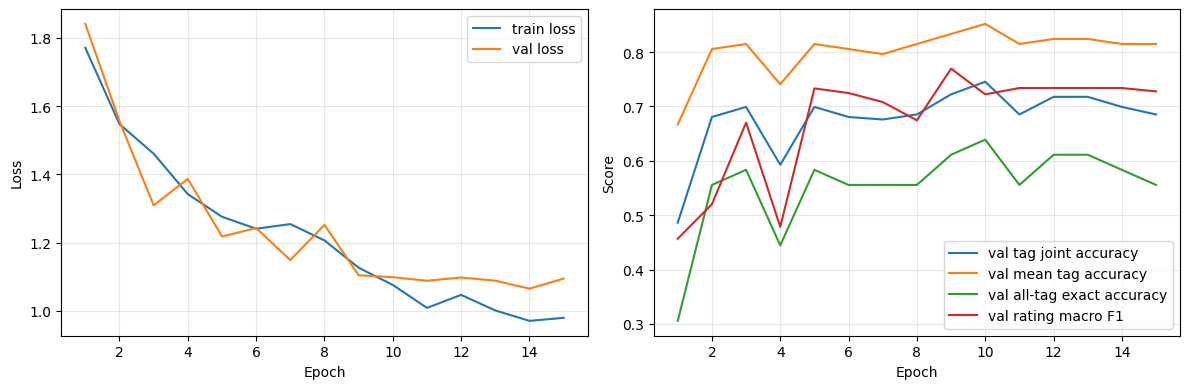

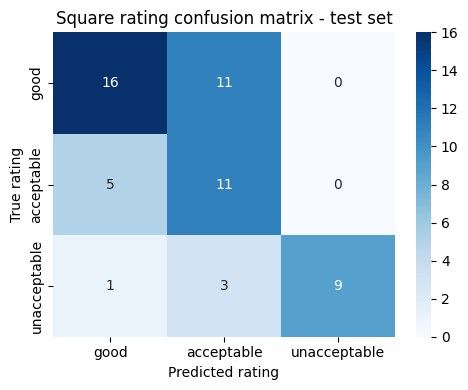

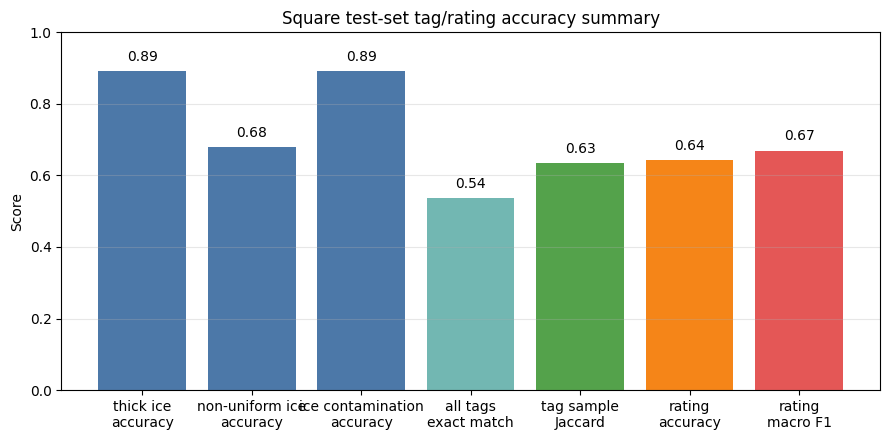

In [13]:
def plot_training_curves(history_df, output_path):
    if history_df.empty:
        print("No training history to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    for column, label in [
        ("val_tag_joint_accuracy", "val tag joint accuracy"),
        ("val_tag_mean_accuracy", "val mean tag accuracy"),
        ("val_tag_exact_match", "val all-tag exact accuracy"),
        ("val_rating_macro_f1", "val rating macro F1"),
    ]:
        if column in history_df:
            axes[1].plot(history_df["epoch"], history_df[column], label=label)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


def plot_confusion_matrix(cm, output_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    if sns is not None:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=RATING_CLASSES, yticklabels=RATING_CLASSES, ax=ax)
    else:
        image = ax.imshow(cm, cmap="Blues")
        fig.colorbar(image, ax=ax)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
        ax.set_xticks(range(len(RATING_CLASSES)), RATING_CLASSES, rotation=45, ha="right")
        ax.set_yticks(range(len(RATING_CLASSES)), RATING_CLASSES)
    ax.set_xlabel("Predicted rating")
    ax.set_ylabel("True rating")
    ax.set_title("Square rating confusion matrix - test set")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


def plot_metric_summary_bars(preds, tag_thresholds, metrics, output_path):
    tag_true = preds["tag_true"]
    tag_pred = apply_tag_thresholds(preds["tag_probs"], tag_thresholds)
    values = []
    labels = []
    for i, tag in enumerate(TAG_CLASSES):
        labels.append(f"{tag}\naccuracy")
        values.append(float((tag_true[:, i] == tag_pred[:, i]).mean()))
    labels.extend(["all tags\nexact match", "tag sample\nJaccard", "rating\naccuracy", "rating\nmacro F1"])
    values.extend([
        float(metrics.get("tag_exact_match_accuracy", np.nan)),
        float(metrics.get("tag_sample_jaccard", np.nan)),
        float(metrics.get("rating_accuracy", np.nan)),
        float(metrics.get("rating_macro_f1", np.nan)),
    ])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(labels, values, color=["#4c78a8"] * len(TAG_CLASSES) + ["#72b7b2", "#54a24b", "#f58518", "#e45756"])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.set_title("Square test-set tag/rating accuracy summary")
    ax.grid(axis="y", alpha=0.3)
    for bar, value in zip(bars, values):
        if np.isfinite(value):
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


plot_training_curves(pd.DataFrame(history), RUN_DIR / "training_curves.png")
plot_confusion_matrix(test_cm, RUN_DIR / "rating_confusion_matrix.png")
plot_metric_summary_bars(test_preds, tag_thresholds, test_metrics, RUN_DIR / "metric_summary_bars.png")

## 14. Save Run Summary

In [14]:
summary_lines = [
    "# Square Experiment B ResNet18 Summary",
    "",
    f"Run directory: `{RUN_DIR}`",
    f"Labels file: `{CSV_PATH}`",
    f"Image directory: `{IMAGE_DIR}`",
    f"Device: `{DEVICE}`",
    f"Image size: {CFG.image_size}",
    f"Rows loaded: {len(raw_df):,}",
    f"Rows with matched images: {len(trainable_df):,}",
    f"No-tag/no-issue rows kept as all-zero targets: {(trainable_df['tags_list'].str.len() == 0).sum():,}",
    f"Rows excluded for only-unmapped source tags: {len(excluded_unmapped_only_df) if CFG.exclude_only_unmapped_tag_rows else 0:,}",
    f"Invalid ratings masked from rating training/metrics: {len(invalid_rating_rows):,}",
    f"Missing images: {len(missing_images):,}",
    "",
    "## Splits",
    f"Train: {len(train_df):,}",
    f"Validation: {len(val_df):,}",
    f"Test: {len(test_df):,}",
    "",
    "## Thresholds",
    f"Tag thresholds: `{tag_thresholds}`",
    f"Tag threshold objective: `{CFG.tag_threshold_objective}`",
    f"Individual-tag accuracy weight: `{CFG.tag_specific_accuracy_weight}`",
    f"Whole-tag-set exact-match weight: `{CFG.tag_exact_match_accuracy_weight}`",
    f"Threshold search: `{tag_threshold_search_info}`",
    f"Minimum tag thresholds: `{CFG.minimum_tag_thresholds}`",
    f"Tag positive weighting enabled: `{CFG.use_tag_pos_weight}`",
    "Rating prediction rule: `unacceptable threshold, then good/acceptable argmax`",
    f"Unacceptable probability threshold: `{rating_threshold}`",
    f"Rating threshold objective: `{CFG.rating_threshold_objective}`",
    "",
    "## Test Metrics",
    f"Tag mean individual accuracy: {test_metrics.get('tag_mean_accuracy')}",
    f"Tag minimum individual accuracy: {test_metrics.get('tag_min_accuracy')}",
    f"Tag joint accuracy: {test_metrics.get('tag_joint_accuracy')}",
    f"Tag exact match accuracy: {test_metrics.get('tag_exact_match_accuracy')}",
    f"Tag macro balanced accuracy: {test_metrics.get('tag_macro_balanced_accuracy')}",
    f"Tag micro F1: {test_metrics.get('tag_micro_f1')}",
    f"Tag macro F1: {test_metrics.get('tag_macro_f1')}",
    f"Tag sample Jaccard: {test_metrics.get('tag_sample_jaccard')}",
    f"Rating accuracy: {test_metrics.get('rating_accuracy')}",
    f"Rating macro F1: {test_metrics.get('rating_macro_f1')}",
    f"Unacceptable precision: {test_metrics.get('unacceptable_precision')}",
    f"Unacceptable recall: {test_metrics.get('unacceptable_recall')}",
    f"Unacceptable F1: {test_metrics.get('unacceptable_f1')}",
    "",
    "## Error Review",
    f"False-negative unacceptable examples: {len(false_negative_unacceptable)}",
    f"False-positive unacceptable examples: {len(false_positive_unacceptable)}",
    "",
    "## Key Artifacts",
    "- preprocessing_examples.png",
    "- metric_summary_bars.png",
    "- training_curves.png",
    "- rating_confusion_matrix.png",
    "- tag_threshold_report.csv",
    "- tag_threshold_sweep.csv",
    "- tag_threshold_top_combinations.csv",
    "- rating_threshold_sweep.csv",
    "- false_negative_unacceptable.csv",
    "- uncertain_examples_for_review.csv",
    "- prediction_csv.csv",
]
(RUN_DIR / "run_summary.md").write_text("\n".join(summary_lines), encoding="utf-8")
print("Saved run summary and artifacts in:", RUN_DIR)

Saved run summary and artifacts in: /nsls2/users/mnicholso/cryoemdoc_prototype/outputs/square_analyzer


## 15. Repeated-Run Robustness Summary

To judge whether Square Experiment is truly improving, rerun this notebook several times with different `CFG.seed` values and unique output directories. This cell summarizes those runs so you can look at mean/stdev instead of trusting one small test split.

In [15]:
def summarize_experiment_b_runs(outputs_dir: Path = OUTPUTS_DIR):
    rows = []
    for run_dir in sorted(outputs_dir.glob("square_analyzer*")):
        metrics_path = run_dir / "validation_test_metrics.json"
        thresholds_path = run_dir / "thresholds.json"
        metadata_path = run_dir / "best_model_metadata.json"
        if not metrics_path.exists():
            continue
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        thresholds = json.loads(thresholds_path.read_text(encoding="utf-8")) if thresholds_path.exists() else {}
        metadata = json.loads(metadata_path.read_text(encoding="utf-8")) if metadata_path.exists() else {}
        config = metadata.get("config", {})
        row = {
            "run_dir": str(run_dir),
            "seed": config.get("seed"),
            "best_epoch": metadata.get("epoch"),
            "best_phase": metadata.get("phase"),
            "rating_threshold": thresholds.get("rating_threshold"),
        }
        for split in ["validation", "test"]:
            split_metrics = metrics.get(split, {})
            for key in [
                "tag_mean_accuracy",
                "tag_min_accuracy",
                "tag_joint_accuracy",
                "tag_macro_balanced_accuracy",
                "tag_macro_f1",
                "tag_exact_match_accuracy",
                "tag_sample_jaccard",
                "rating_accuracy",
                "rating_macro_f1",
                "unacceptable_precision",
                "unacceptable_recall",
                "unacceptable_f1",
            ]:
                row[f"{split}_{key}"] = split_metrics.get(key)
        rows.append(row)
    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        print("No completed Experiment B runs found yet.")
        return summary_df
    summary_df.to_csv(outputs_dir / "square_experiment_b_repeated_run_summary.csv", index=False)
    display(summary_df.sort_values("run_dir"))
    metric_cols = [col for col in summary_df.columns if col.startswith("test_") or col.startswith("validation_")]
    display(summary_df[metric_cols].agg(["mean", "std", "min", "max"]))
    return summary_df


# Run after you have several Experiment B output directories from different CFG.seed values.
# repeated_run_summary_df = summarize_experiment_b_runs()

## 16. Inference Helpers

In [16]:
def load_model_for_inference(model_state_path: Path = RUN_DIR / "best_model_state.pt"):
    inference_model = ResNet18SquareExperiment(len(TAG_CLASSES), len(RATING_CLASSES), pretrained=False).to(DEVICE)
    state = torch.load(model_state_path, map_location=DEVICE, weights_only=True)
    inference_model.load_state_dict(state)
    inference_model.eval()
    return inference_model


def load_thresholds_for_inference(thresholds_path: Path = RUN_DIR / "thresholds.json") -> Dict[str, Any]:
    default_thresholds = {
        "tag_thresholds": {tag: CFG.tag_probability_threshold for tag in TAG_CLASSES},
        "rating_threshold": CFG.rating_probability_threshold,
        "rating_prediction_rule": "unacceptable_threshold_then_good_acceptable_argmax",
    }
    if thresholds_path.exists():
        loaded = json.loads(thresholds_path.read_text(encoding="utf-8"))
        loaded.setdefault("tag_thresholds", default_thresholds["tag_thresholds"])
        loaded.setdefault("rating_threshold", default_thresholds["rating_threshold"])
        loaded.setdefault("rating_prediction_rule", default_thresholds["rating_prediction_rule"])
        return loaded
    return default_thresholds


@torch.no_grad()
def predict_one_image(
    image_path: str | Path,
    inference_model: Optional[ResNet18SquareExperiment] = None,
    thresholds: Optional[Dict[str, Any]] = None,
    no_issue_label: str = "no issues",
):
    image_path = Path(image_path)
    inference_model = inference_model or model
    thresholds = thresholds or globals().get("threshold_payload") or load_thresholds_for_inference()
    image = Image.open(image_path).convert("L")
    tensor = eval_transform(image).unsqueeze(0).to(DEVICE)
    outputs = inference_model(tensor)
    tag_probs = torch.sigmoid(outputs["tag_logits"])[0].detach().cpu().numpy()
    rating_probs = torch.softmax(outputs["rating_logits"], dim=1)[0].detach().cpu().numpy()
    tag_pred = apply_tag_thresholds(tag_probs[None, :], thresholds["tag_thresholds"])[0]
    predicted_tags = postprocess_predicted_tags(tags_from_binary(tag_pred, no_issue_label=None) or ["no tags"])
    predicted_rating_idx = apply_rating_threshold(rating_probs[None, :], thresholds.get("rating_threshold", CFG.rating_probability_threshold))[0]
    predicted_rating = IDX_TO_RATING[int(predicted_rating_idx)]
    return {
        "image_path": str(image_path),
        "predicted_tags": predicted_tags,
        "recommendations": recommendations_from_tags(predicted_tags),
        "tag_probabilities": {tag: float(tag_probs[i]) for i, tag in enumerate(TAG_CLASSES)},
        "predicted_rating": predicted_rating,
        "rating_probabilities": {rating: float(rating_probs[i]) for i, rating in enumerate(RATING_CLASSES)},
    }


@torch.no_grad()
def predict_folder(folder: str | Path, inference_model=None, thresholds=None):
    rows = []
    for path in sorted(Path(folder).rglob("*")):
        if path.suffix.lower() not in IMAGE_EXTS:
            continue
        pred = predict_one_image(path, inference_model=inference_model, thresholds=thresholds)
        row = {
            "image_path": pred["image_path"],
            "predicted_tags": pred["predicted_tags"] if isinstance(pred["predicted_tags"], str) else "; ".join(pred["predicted_tags"]),
            "recommendations": "; ".join(pred["recommendations"]),
            "predicted_rating": pred["predicted_rating"],
        }
        row.update({f"prob_tag__{k}": v for k, v in pred["tag_probabilities"].items()})
        row.update({f"prob_rating__{k}": v for k, v in pred["rating_probabilities"].items()})
        rows.append(row)
    return pd.DataFrame(rows)


# Example after training:
# model_for_inference = load_model_for_inference()
# new_predictions = predict_folder("/path/to/new/square/folder", inference_model=model_for_inference)
# new_predictions.to_csv(RUN_DIR / "new_folder_predictions.csv", index=False)

In [17]:
model_for_inference = load_model_for_inference()

new_predictions = predict_folder(
    "/nsls2/users/mnicholso/cryoemdoc_prototype/data/Square_testing",
    inference_model=model_for_inference,
)

new_predictions.to_csv(RUN_DIR / "new_square_predictions.csv", index=False)
new_predictions.head()

,image_path,predicted_tags,recommendations,predicted_rating,prob_tag__thick ice,prob_tag__non-uniform ice,prob_tag__ice contamination,prob_rating__good,prob_rating__acceptable,prob_rating__unacceptable
0,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no recommendation,good,0.023605,0.025604,0.149717,0.799803,0.198582,0.001615
1,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no recommendation,good,0.017418,0.012700,0.107897,0.781949,0.217440,0.000611
2,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,thick ice,increase blotting force/time,acceptable,0.520756,0.266431,0.178017,0.200284,0.739070,0.060646
3,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,thick ice,increase blotting force/time,acceptable,0.389222,0.283662,0.168456,0.232753,0.719202,0.048044
4,/nsls2/users/mnicholso/cryoemdoc_prototype/dat...,no tags,no recommendation,good,0.012995,0.066827,0.149802,0.808569,0.189088,0.002343
